# 06 - Modeling - Same Agency Pool

In [1]:
ENV = "local"

from pathlib import Path

if ENV == "colab":
    DATA_DIR = Path("/content/drive/MyDrive/thesis")
else:
    DATA_DIR = Path("00_data")

if ENV == "colab":
    from google.colab import drive
    drive.mount('/content/drive')


In [ ]:
import re

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, average_precision_score,
    classification_report, roc_auc_score,  ConfusionMatrixDisplay,
)
from sklearn.metrics import roc_auc_score as _auc
from sklearn.model_selection import (
    GridSearchCV, StratifiedKFold, cross_val_score,
    cross_validate, train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MaxAbsScaler, FunctionTransformer
from sklearn.base import clone

from xgboost import XGBClassifier

import shap

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import seaborn as sns

from tqdm.auto import tqdm as _tqdm

import optuna
import lightgbm as lgb
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
optuna.logging.set_verbosity(optuna.logging.WARNING)

ModuleNotFoundError: No module named 'lightgbm'

# Data

In [8]:
df = pd.read_parquet(str( DATA_DIR / '05_sa.parquet'))
df

,title,description,publisher,identifier,slug,has_spatial,popularity,last_harvested_date,keyword,theme,...,unique_pen_words_title,unique_nyt_words_title,flagged_words_all_abstract,flagged_words_all_title,total_flagged_terms_total,unique_flagged_words_total,has_flagged_word_total,has_flagged_terms_total,avg_repetition,flagged_ratio
0,NNDSS - TABLE 1M. Gonorrhea to Haemophilus inf...,NNDSS - TABLE 1M. Gonorrhea to Haemophilus inf...,Centers for Disease Control and Prevention,https://data.cdc.gov/api/views/h4wb-nae4,nndss-table-1m-gonorrhea-to-haemophilus-influe...,0,0,2025-08-08T15:20:14.743931,"[2019, age <5 years, all ages, all serotypes, ...",[NNDSS],...,0,0,,,0,0,0,0,0.0,0.000000
1,Environmental Protection Agency (EPA) Regions,Homeland Infrastructure Foundation-Level Data ...,HIFLD,MGMT-GMO-HIFLD-677626,environmental-protection-agency-epa-regions,0,0,2025-08-02T09:16:41.425325,[none],[],...,0,0,,,0,0,0,0,0.0,0.000000
2,NNDSS - Table II. West Nile virus disease,NNDSS - Table II. West Nile virus disease - 20...,Centers for Disease Control and Prevention,https://data.cdc.gov/api/views/sd5c-m3g5,nndss-table-ii-west-nile-virus-disease-e9366,0,0,2025-08-09T04:32:37.333085,"[2016, mmwr, nedss, netss, nndss, west nile vi...",[NNDSS],...,0,0,,,0,0,0,0,0.0,0.000000
3,COVID-19 Vaccination Trends in the United Stat...,Overall Trends in Number of COVID-19 Vaccinati...,Centers for Disease Control and Prevention,https://data.cdc.gov/api/views/rh2h-3yt2,covid-19-vaccination-trends-in-the-united-stat...,1,0,2025-08-09T03:35:34.294662,"[administration, coronavirus, covid-19, immuni...",[Vaccinations],...,1,0,covid-19,covid-19,0,2,1,0,0.0,0.000000
4,American Time Use Survey,The American Time Use Survey (ATUS) provides n...,Bureau of Labor Statistics,DOL-BLS-218,american-time-use-survey,0,9,2025-08-02T13:50:25.846114,"[child care, elder care, time use, volunteering]",[],...,0,0,,,0,0,0,0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2509,Franchise Fund FY 2013 Annual Report,<p>Franchise Fund FY 2013 Annual Report</p>,Department of Veterans Affairs,VA-OM-OM-032,franchise-fund-fy-2013-annual-report,0,1,2025-08-08T08:20:27.163330,"[annual report, franchise fund, fy 2013]",[Financial],...,0,0,,,0,0,0,0,0.0,0.000000
2510,NNDSS - Table II. Chlamydia to Coccidioidomycosis,NNDSS - Table II. Chlamydia to Coccidioidomyco...,Centers for Disease Control and Prevention,https://data.cdc.gov/api/views/n835-hpyp,nndss-table-ii-chlamydia-to-coccidioidomycosis...,0,0,2025-08-08T22:07:07.949127,"[2016, chlamydia trachomatis infection, coccid...",[NNDSS],...,0,0,,,0,0,0,0,0.0,0.000000
2511,U.S. State and Territorial Public Mask Mandate...,"State and territorial executive orders, admini...",Centers for Disease Control and Prevention,https://data.cdc.gov/api/views/42jj-z7fa,u-s-state-and-territorial-public-mask-mandates...,0,0,2025-08-08T19:47:44.252563,"[covid-19, executive order, government order, ...",[Policy Surveillance],...,0,0,accessible; community; covid-19; excluded; tribal,,4,5,1,1,0.8,0.011396
2512,Submerged Land Act (SLA) Boundary,Homeland Infrastructure Foundation-Level Data ...,HIFLD,MGMT-GMO-HIFLD-407158,submerged-land-act-sla-boundary,0,0,2025-08-02T09:02:39.857358,[none],[],...,0,0,,,0,0,0,0,0.0,0.000000


In [9]:
def stratified_cv_splits(y, n_splits=5, test_size=0.2, random_state=42):

    idx = np.arange(len(y))
    trainval_idx, test_idx = train_test_split(
        idx, test_size=test_size, stratify=y, random_state=random_state
    )
    kfold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    folds = [(trainval_idx[tr], trainval_idx[val])
             for tr, val in kfold.split(trainval_idx, y[trainval_idx])]
    return folds, test_idx


In [10]:
y_full = df['label'].values
folds, test_idx = stratified_cv_splits(y_full)

trainval_idx = np.setdiff1d(np.arange(len(df)), test_idx)
df_tv = df.iloc[trainval_idx].copy()
df_te = df.iloc[test_idx].copy()

print(f'train + val: {len(df_tv):,}, hold out: {len(df_te):,}')
print(f'positive rate - train + val: {y_full[trainval_idx].mean():.3f}, test: {y_full[test_idx].mean():.3f}')
print(f'fold sizes (train, val): {[(len(tr), len(va)) for tr, va in folds]}')


train + val: 2,011, hold out: 503
positive rate - train + val: 0.522, test: 0.523
fold sizes (train, val): [(1608, 403), (1609, 402), (1609, 402), (1609, 402), (1609, 402)]


# SRQ1: Baselines

In [11]:
def make_lr_variants(max_iter):
    Cs = [0.001, 0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 50.0, 100.0]

    def make_gscv(solver, l1_ratio=0.0):
        kwargs = {'l1_ratio': l1_ratio} if l1_ratio else {}
        return GridSearchCV(
            LogisticRegression(solver=solver, max_iter=max_iter, class_weight='balanced', **kwargs),
            param_grid={'C': Cs}, scoring='average_precision', cv=5, n_jobs=-1, refit=True,
        )

    return {
        'LR-L2':    lambda: LogisticRegression(solver='lbfgs', max_iter=max_iter, class_weight='balanced'),
        'LR-L1':    lambda: LogisticRegression(l1_ratio=1.0, solver='liblinear', max_iter=max_iter, class_weight='balanced'),
        'LR-CV-L2': lambda: make_gscv('lbfgs'),
        'LR-CV-L1': lambda: make_gscv('liblinear', l1_ratio=1.0),
    }

def get_best_c(clf):
    if hasattr(clf, 'best_params_'):
        return clf.best_params_['C']
    return None

## 1. Majority class

In [12]:
X_b1 = np.zeros((len(df), 1))

dummy = DummyClassifier(strategy='most_frequent')
cv_b1 = cross_validate(dummy, X_b1, y_full, cv=folds, scoring=['roc_auc', 'average_precision', 'accuracy'], return_train_score=True)

print(f'cv roc auc: {cv_b1['test_roc_auc'].mean():.4f} ± {cv_b1['test_roc_auc'].std():.4f}')
print(f'cv auc pr: {cv_b1['test_average_precision'].mean():.4f} ± {cv_b1['test_average_precision'].std():.4f}')
print(f'cv accuracy: {cv_b1['test_accuracy'].mean():.4f} ± {cv_b1['test_accuracy'].std():.4f}')

cv roc auc: 0.5000 ± 0.0000
cv auc pr: 0.5221 ± 0.0005
cv accuracy: 0.5221 ± 0.0005


In [13]:
dummy.fit(X_b1[trainval_idx], y_full[trainval_idx])
y_prob = dummy.predict_proba(X_b1[test_idx])[:, 1]
test_auc = roc_auc_score(y_full[test_idx], y_prob)
test_aucpr = average_precision_score(y_full[test_idx], y_prob)
print(f'test roc auc: {test_auc:.4f}')
print(f'test auc pr: {test_aucpr:.4f}')
print(f'test Accuracy: {accuracy_score(y_full[test_idx], dummy.predict(X_b1[test_idx])):.4f}')

test roc auc: 0.5000
test auc pr: 0.5229
test Accuracy: 0.5229


## 2. Keyword count

In [14]:
X_b2 = df[['flagged_ratio']].values

for name, clf_fn in make_lr_variants(1000).items():
    cv = cross_validate(clf_fn(), X_b2, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b2[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_b2[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    print(f'flagged word ratio ({name})')
    print(f'cv roc auc: {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'cv auc pr: {cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}')
    print(f'cv accuracy: { cv["test_accuracy"].mean():.4f} ± { cv["test_accuracy"].std():.4f}')
    print(f'test roc auc: {test_auc:.4f}, test auc pr: {test_aucpr:.4f}')
    best_c = get_best_c(clf)
    if best_c: print(f'best c: {best_c:.4f}')
    print()

flagged word ratio (LR-L2)
cv roc auc: 0.5419 ± 0.0266
cv auc pr: 0.5587 ± 0.0291
cv accuracy: 0.5231 ± 0.0265
test roc auc: 0.5260, test auc pr: 0.5630

flagged word ratio (LR-L1)
cv roc auc: 0.5280 ± 0.0266
cv auc pr: 0.5419 ± 0.0192
cv accuracy: 0.5017 ± 0.0238
test roc auc: 0.5260, test auc pr: 0.5630

flagged word ratio (LR-CV-L2)
cv roc auc: 0.5419 ± 0.0266
cv auc pr: 0.5587 ± 0.0291
cv accuracy: 0.5221 ± 0.0005
test roc auc: 0.5260, test auc pr: 0.5630
best c: 0.0010

flagged word ratio (LR-CV-L1)
cv roc auc: 0.5419 ± 0.0266
cv auc pr: 0.5587 ± 0.0291
cv accuracy: 0.5166 ± 0.0270
test roc auc: 0.5260, test auc pr: 0.5630
best c: 1.0000



## 3. TF-IDF + logistic regression

vectorizer fit per fold

In [15]:
X_b3_full = df['all_text'].to_numpy(dtype=object)


In [16]:
vec = TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True, stop_words='english')
vec.fit(X_b3_full[trainval_idx])
print(f'Total unique ngrams (trainval): {len(vec.vocabulary_):,}')

Total unique ngrams (trainval): 76,484


In [ ]:
candidates = [1_000, 2_500, 5_000, 10_000, 25_000, 50_000]
aucs = []
for n in candidates:
    pipe = Pipeline([('tfidf', TfidfVectorizer(max_features=n, ngram_range=(1, 2), sublinear_tf=True, stop_words='english')),
        ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))])

    score = cross_val_score(pipe, X_b3_full, y_full, cv=folds, scoring='roc_auc').mean()
    aucs.append(score)
    print(f'{n:>6,}  AUC={score:.4f}')

plt.figure(figsize=(7, 4))
plt.plot(candidates, aucs, marker='o')
plt.xscale('log')
plt.xlabel('max_features')
plt.ylabel('roc auc')
plt.title('tf idf vocab size vs auc')
plt.tight_layout()
plt.show()

 1,000  AUC=0.8858


KeyboardInterrupt: 

In [ ]:
for name, clf_fn in make_lr_variants(1000).items():
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5_000, ngram_range=(1, 2),
                                  sublinear_tf=True, stop_words='english')),
        ('lr', clf_fn())])

    cv = cross_validate(pipe, X_b3_full, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    pipe2 = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=5_000, ngram_range=(1, 2),
                                  sublinear_tf=True, stop_words='english')),
        ('lr', clf_fn())])

    pipe2.fit(X_b3_full[trainval_idx], y_full[trainval_idx])
    y_prob = pipe2.predict_proba(X_b3_full[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    print(f'tf idf {name}')
    print(f'cv roc auc: {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'cv auc pr: {cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}')
    print(f'cv acccuracy: { cv["test_accuracy"].mean():.4f} ± { cv["test_accuracy"].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  test auc pr: {test_aucpr:.4f}')
    best_c = get_best_c(pipe2['lr'])
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()

tf idf LR-L2
cv roc auc: 0.9031 ± 0.0163
cv auc pr: 0.9088 ± 0.0208
cv acccuracy: 0.8284 ± 0.0242
test roc auc: 0.9077 ,  test auc pr: 0.9140

tf idf LR-L1
cv roc auc: 0.8603 ± 0.0224
cv auc pr: 0.8469 ± 0.0226
cv acccuracy: 0.8056 ± 0.0252
test roc auc: 0.8654 ,  test auc pr: 0.8630

tf idf LR-CV-L2
cv roc auc: 0.9131 ± 0.0135
cv auc pr: 0.9185 ± 0.0149
cv acccuracy: 0.8364 ± 0.0171
test roc auc: 0.9216 ,  test auc pr: 0.9326
best c: 5.0000

tf idf LR-CV-L1
cv roc auc: 0.8881 ± 0.0184
cv auc pr: 0.8698 ± 0.0155
cv acccuracy: 0.8289 ± 0.0239
test roc auc: 0.8978 ,  test auc pr: 0.9033
best c: 5.0000



### 4. Sentence embeddings + logistic regression

In [17]:
embed_cols = ['title_embeddings_nomic', 'desc_embeddings_nomic']

title_embs = np.array(df['title_embeddings_nomic'].tolist(), dtype=np.float32)
desc_embs = np.array(df['desc_embeddings_nomic'].tolist(),  dtype=np.float32)
X_b4_full = np.hstack([title_embs, desc_embs])

assert X_b4_full.shape[0] == len(df), 'row count mismatch'
assert X_b4_full.dtype == np.float32, 'dtype mismatch - expected float32'
print(f'embedding matrix: {X_b4_full.shape}  dtype={X_b4_full.dtype}')
print(f'  title embs: {title_embs.shape},  desc embs: {desc_embs.shape}')


embedding matrix: (2514, 1536)  dtype=float32
  title embs: (2514, 768),  desc embs: (2514, 768)


In [ ]:
for name, clf_fn in make_lr_variants(5000).items():
    cv = cross_validate(clf_fn(), X_b4_full, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b4_full[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_b4_full[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    print(f'sentence embeddings ({name})')
    print(f'cv roc auc: {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'cv auc pr: {cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}')
    print(f'cv accuracy: { cv["test_accuracy"].mean():.4f} ± { cv["test_accuracy"].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  Test auc pr: {test_aucpr:.4f}')
    best_c = get_best_c(clf)
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()

sentence embeddings (LR-L2)
cv roc auc: 0.8739 ± 0.0127
cv auc pr: 0.8874 ± 0.0182
cv accuracy: 0.7892 ± 0.0148
test roc auc: 0.8761 ,  Test auc pr: 0.8900

sentence embeddings (LR-L1)
cv roc auc: 0.8592 ± 0.0086
cv auc pr: 0.8718 ± 0.0141
cv accuracy: 0.7653 ± 0.0076
test roc auc: 0.8619 ,  Test auc pr: 0.8803

sentence embeddings (LR-CV-L2)
cv roc auc: 0.8877 ± 0.0136
cv auc pr: 0.8995 ± 0.0157
cv accuracy: 0.8016 ± 0.0119
test roc auc: 0.8975 ,  Test auc pr: 0.8983
best c: 5.0000

sentence embeddings (LR-CV-L1)
cv roc auc: 0.8726 ± 0.0110
cv auc pr: 0.8833 ± 0.0134
cv accuracy: 0.7941 ± 0.0107
test roc auc: 0.8998 ,  Test auc pr: 0.8951
best c: 5.0000



# SRQ2: Metadata

Feature groups

In [18]:
flagged_cols = [
    'total_flagged_terms_total',
    'unique_flagged_words_total',
    'total_pen_terms_abstract',
    'total_nyt_terms_abstract',
    'has_flagged_word_total',
    'avg_repetition',
    'flagged_ratio',
]

text_prop_cols = ['desc_length',
                  'title_length',
                  'desc_word_count']


# dropped: has_spatial, n_themes
engagement_cols = ['popularity',
                   'n_keywords']

# dropped: has_issued
temporal_cols = []

# dropped: has_bureau_code, has_program_code, has_temporal_info
completeness_cols = [
    'has_license',
    'has_periodicity',
    'has_landing_page',
    'org_type_federal',
]

org_cat_cols = ['org_type']
access_cat_cols = ['dcat_access_level']

all_meta_num = flagged_cols + text_prop_cols + engagement_cols + temporal_cols + completeness_cols
all_meta_cat = org_cat_cols + access_cat_cols
input_cols = ['all_text'] + all_meta_num + all_meta_cat

ablation_conditions = {
    'text only': ([], []),
    'text + flagged risk': (flagged_cols,[]),
    'text + text properties': (text_prop_cols, []),
    'text + engagement': (engagement_cols, []),
    'text + completeness': (completeness_cols,[]),
    'text + access level': ([], access_cat_cols),
    'text + org type': ([], org_cat_cols),
    'text + all metadata': (all_meta_num, all_meta_cat),
}

meta_ablation_conditions = {
    'flagged terms': (flagged_cols, []),
    'text properties': (text_prop_cols, []),
    'engagement': (engagement_cols, []),
    'completeness': (completeness_cols,[]),
    'org type': ([], org_cat_cols),
    'access level': ([], access_cat_cols),
    'all numerical': (all_meta_num, []),
    'all categorical': ([], all_meta_cat),
    'all metadata': (all_meta_num,  all_meta_cat),
}

### 5. Metadata only

In [19]:
num_cols_b5 = all_meta_num
cat_cols_b5 = all_meta_cat

X_b5 = df[num_cols_b5 + cat_cols_b5]

pre_b5 = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols_b5),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_b5),
], remainder='drop')

In [ ]:
for name, clf_fn in make_lr_variants(10_000).items():
    pipe = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    cv = cross_validate(pipe, X_b5, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    pipe2 = Pipeline([('pre', pre_b5), ('clf', clf_fn())])
    pipe2.fit(X_b5.iloc[trainval_idx], y_full[trainval_idx])
    y_prob = pipe2.predict_proba(X_b5.iloc[test_idx])[:, 1]
    test_auc  = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    print(f'metadata ({name})')
    print(f'cv roc auc: {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'cv auc pr: {cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}')
    print(f'cv accuracy: { cv["test_accuracy"].mean():.4f} ± { cv["test_accuracy"].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  Test auc pr: {test_aucpr:.4f}')
    best_c = get_best_c(pipe2['clf'])
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()


metadata (LR-L2)
cv roc auc: 0.6966 ± 0.0196
cv auc pr: 0.7191 ± 0.0152
cv accuracy: 0.6489 ± 0.0125
test roc auc: 0.7199 ,  Test auc pr: 0.7183

metadata (LR-L1)
cv roc auc: 0.6960 ± 0.0190
cv auc pr: 0.7191 ± 0.0114
cv accuracy: 0.6509 ± 0.0111
test roc auc: 0.7199 ,  Test auc pr: 0.7186

metadata (LR-CV-L2)
cv roc auc: 0.6978 ± 0.0202
cv auc pr: 0.7197 ± 0.0148
cv accuracy: 0.6549 ± 0.0099
test roc auc: 0.7198 ,  Test auc pr: 0.7185
best c: 5.0000

metadata (LR-CV-L1)
cv roc auc: 0.6967 ± 0.0182
cv auc pr: 0.7166 ± 0.0125
cv accuracy: 0.6539 ± 0.0075
test roc auc: 0.7194 ,  Test auc pr: 0.7180
best c: 5.0000



feature improtance from best regularised model

In [ ]:
lrcv_pipe = Pipeline([('pre', pre_b5), ('clf', make_lr_variants(10_000)['LR-CV-L2']())])
lrcv_pipe.fit(X_b5.iloc[trainval_idx], y_full[trainval_idx])
feature_names = (num_cols_b5 + lrcv_pipe['pre'].named_transformers_['cat'].get_feature_names_out(cat_cols_b5).tolist())

pd.DataFrame({'feature':  feature_names,'coefficient': lrcv_pipe['clf'].best_estimator_.coef_[0]}).sort_values('coefficient', ascending=False)

,feature,coefficient
7,desc_length,2.979009
0,total_flagged_terms_total,1.684518
19,org_type_State Government,0.803125
21,dcat_access_level_public,0.765550
14,has_landing_page,0.457036
1,unique_flagged_words_total,0.439826
17,org_type_County Government,0.266910
10,popularity,0.208498
15,org_type_federal,0.168316
12,has_license,0.133859


### Feature ablation

In [20]:
def make_ablation_pipeline(num_cols, cat_cols, include_text=True):
    transformers = []
    if include_text:
        transformers.append(
            ('tfidf', TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                                      sublinear_tf=True, stop_words='english'), 'all_text')
        )
    if num_cols:
        transformers.append(
            ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols)
        )
    if cat_cols:
        transformers.append(
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        )
    pre = ColumnTransformer(transformers, remainder='drop', sparse_threshold=0)
    return Pipeline([
        ('pre', pre),
        ('lr',  LogisticRegression(solver='lbfgs',
                                   max_iter=5000, class_weight='balanced')),
    ])

#### Metadata only

In [ ]:
X_meta_abl = df[all_meta_num + all_meta_cat]

meta_abl_results = []
for cond_name, (num_cols, cat_cols) in meta_ablation_conditions.items():
    if not num_cols and not cat_cols:
        print(f'skip {cond_name}')
        continue
    pipe = make_ablation_pipeline(num_cols, cat_cols, include_text=False)
    cv = cross_validate(pipe, X_meta_abl, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    pipe.fit(X_meta_abl.iloc[trainval_idx], y_full[trainval_idx])
    y_prob = pipe.predict_proba(X_meta_abl.iloc[test_idx])[:, 1]
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    meta_abl_results.append({
        'condition': cond_name,
        'cv_aucpr': f'{cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}',
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f'{cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}',
        'test_auc': round(test_auc, 4),
    })
    print(f'{cond_name:<20}  cv_pr={cv["test_average_precision"].mean():.4f}  '
          f'test_pr={test_aucpr:.4f}  cv_auc={cv["test_roc_auc"].mean():.4f}  '
          f'test_auc={test_auc:.4f}')

flagged terms         cv_pr=0.5841  test_pr=0.5893  cv_auc=0.5477  test_auc=0.5609
text properties       cv_pr=0.6367  test_pr=0.6024  cv_auc=0.5917  test_auc=0.5609
engagement            cv_pr=0.5358  test_pr=0.5780  cv_auc=0.5014  test_auc=0.5559
completeness          cv_pr=0.6213  test_pr=0.6510  cv_auc=0.6430  test_auc=0.6809
org type              cv_pr=0.5232  test_pr=0.5251  cv_auc=0.5000  test_auc=0.5045
access level          cv_pr=0.5369  test_pr=0.5381  cv_auc=0.5286  test_auc=0.5296
all numerical         cv_pr=0.7068  test_pr=0.7051  cv_auc=0.6827  test_auc=0.7105
all categorical       cv_pr=0.5380  test_pr=0.5406  cv_auc=0.5278  test_auc=0.5343
all metadata          cv_pr=0.7191  test_pr=0.7183  cv_auc=0.6966  test_auc=0.7199


In [ ]:
df_meta_abl = pd.DataFrame(meta_abl_results).sort_values('test_aucpr', ascending=False)
df_meta_abl

,condition,cv_aucpr,test_aucpr,cv_auc,test_auc
8,all metadata,0.7191 ± 0.0152,0.7183,0.6966 ± 0.0196,0.7199
6,all numerical,0.7068 ± 0.0137,0.7051,0.6827 ± 0.0130,0.7105
3,completeness,0.6213 ± 0.0120,0.6510,0.6430 ± 0.0172,0.6809
1,text properties,0.6367 ± 0.0278,0.6024,0.5917 ± 0.0195,0.5609
0,flagged terms,0.5841 ± 0.0111,0.5893,0.5477 ± 0.0087,0.5609
2,engagement,0.5358 ± 0.0415,0.5780,0.5014 ± 0.0664,0.5559
7,all categorical,0.5380 ± 0.0056,0.5406,0.5278 ± 0.0137,0.5343
5,access level,0.5369 ± 0.0027,0.5381,0.5286 ± 0.0053,0.5296
4,org type,0.5232 ± 0.0031,0.5251,0.5000 ± 0.0085,0.5045


In [ ]:
df.groupby('label')['has_flagged_terms_total'].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
0,1201.0,0.249792,0.433073,0.0,0.0,0.0,0.0,1.0
1,1313.0,0.319117,0.466312,0.0,0.0,0.0,1.0,1.0


### 6. Metadata + tf-idf

In [21]:
ablation_runs = list(ablation_conditions.items()) + [
    ('Metadata only', (all_meta_num, all_meta_cat, False)),
]

In [ ]:
X_abl = df[input_cols]

abl_results = []
for item in ablation_runs:
    cond_name, args = item
    if len(args) == 3:
        num_cols, cat_cols, include_text = args
    else:
        num_cols, cat_cols = args
        include_text = True

    pipe = make_ablation_pipeline(num_cols, cat_cols, include_text=include_text)
    cv = cross_validate(pipe, X_abl, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    pipe.fit(X_abl.iloc[trainval_idx], y_full[trainval_idx])
    y_prob  = pipe.predict_proba(X_abl.iloc[test_idx])[:, 1]
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    test_auc = roc_auc_score(y_full[test_idx], y_prob)

    abl_results.append({
        'condition': cond_name,
        'cv_aucpr': f'{cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}',
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f'{cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}',
        'test_auc': round(test_auc, 4),
    })
    print(f'{cond_name:<30}  CV auc pr: {cv["test_average_precision"].mean():.4f}  Test auc pr: {test_aucpr:.4f}  Test  roc auc: {test_auc:.4f}')

df_ablation = pd.DataFrame(abl_results).set_index('condition')
df_ablation


text only                       CV auc pr: 0.9104  Test auc pr: 0.9146  Test  roc auc: 0.9099
text + flagged risk             CV auc pr: 0.9055  Test auc pr: 0.9095  Test  roc auc: 0.9054
text + text properties          CV auc pr: 0.9094  Test auc pr: 0.8924  Test  roc auc: 0.9023
text + engagement               CV auc pr: 0.9093  Test auc pr: 0.8993  Test  roc auc: 0.9111
text + completeness             CV auc pr: 0.9058  Test auc pr: 0.9182  Test  roc auc: 0.9134
text + access level             CV auc pr: 0.9096  Test auc pr: 0.9171  Test  roc auc: 0.9146
text + org type                 CV auc pr: 0.9092  Test auc pr: 0.9130  Test  roc auc: 0.9078
text + all metadata             CV auc pr: 0.8994  Test auc pr: 0.8847  Test  roc auc: 0.9039
Metadata only                   CV auc pr: 0.7191  Test auc pr: 0.7183  Test  roc auc: 0.7199


,cv_aucpr,test_aucpr,cv_auc,test_auc
condition,,,,
text only,0.9104 ± 0.0209,0.9146,0.9045 ± 0.0146,0.9099
text + flagged risk,0.9055 ± 0.0188,0.9095,0.8995 ± 0.0137,0.9054
text + text properties,0.9094 ± 0.0200,0.8924,0.9033 ± 0.0149,0.9023
text + engagement,0.9093 ± 0.0189,0.8993,0.9039 ± 0.0132,0.9111
text + completeness,0.9058 ± 0.0209,0.9182,0.8984 ± 0.0137,0.9134
text + access level,0.9096 ± 0.0210,0.9171,0.9031 ± 0.0141,0.9146
text + org type,0.9092 ± 0.0212,0.9130,0.9027 ± 0.0150,0.9078
text + all metadata,0.8994 ± 0.0185,0.8847,0.8919 ± 0.0156,0.9039
Metadata only,0.7191 ± 0.0152,0.7183,0.6966 ± 0.0196,0.7199


### 7. Metadata + embeddings

In [22]:
num_cols_b6 = all_meta_num
cat_cols_b6 = all_meta_cat

meta_pre_b6 = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols_b6),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_b6),
], remainder='drop')

In [23]:
meta_pre_b6.fit(df.iloc[trainval_idx][num_cols_b6 + cat_cols_b6])
meta_all = meta_pre_b6.transform(df[num_cols_b6 + cat_cols_b6])
print(f'Meta matrix: {meta_all.shape}')

Meta matrix: (2514, 23)


In [24]:
X_b6_full = np.hstack([X_b4_full, meta_all]).astype(np.float32)
print(f'Embeddings + metadata matrix: {X_b6_full.shape}')

Embeddings + metadata matrix: (2514, 1559)


In [ ]:
for name, clf_fn in make_lr_variants(10_000).items():
    cv = cross_validate(clf_fn(), X_b6_full, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision', 'accuracy'],
                        return_train_score=True)
    clf = clf_fn()
    clf.fit(X_b6_full[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_b6_full[test_idx])[:, 1]
    test_auc = roc_auc_score(y_full[test_idx], y_prob)
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)

    print(f'Embeddings + metadata ({name})')
    print(f'cv roc auc: {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'cv auc pr: {cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}')
    print(f'cv accuracy: { cv["test_accuracy"].mean():.4f} ± { cv["test_accuracy"].std():.4f}')
    print(f'test roc auc: {test_auc:.4f} ,  Test auc pr: {test_aucpr:.4f}')

    best_c = get_best_c(clf)
    if best_c is not None: print(f'best c: {best_c:.4f}')
    print()



Embeddings + metadata (LR-L2)
cv roc auc: 0.8698 ± 0.0159
cv auc pr: 0.8798 ± 0.0227
cv accuracy: 0.7906 ± 0.0211
test roc auc: 0.8782 ,  Test auc pr: 0.8638

Embeddings + metadata (LR-L1)
cv roc auc: 0.8569 ± 0.0137
cv auc pr: 0.8664 ± 0.0159
cv accuracy: 0.7772 ± 0.0169
test roc auc: 0.8665 ,  Test auc pr: 0.8596

Embeddings + metadata (LR-CV-L2)
cv roc auc: 0.8832 ± 0.0147
cv auc pr: 0.8907 ± 0.0206
cv accuracy: 0.8026 ± 0.0126
test roc auc: 0.8995 ,  Test auc pr: 0.8826
best c: 5.0000

Embeddings + metadata (LR-CV-L1)
cv roc auc: 0.8722 ± 0.0160
cv auc pr: 0.8769 ± 0.0260
cv accuracy: 0.7976 ± 0.0176
test roc auc: 0.9050 ,  Test auc pr: 0.8778
best c: 5.0000



In [ ]:
abl_emb_results = []

for item in ablation_runs:
    cond_name, args = item
    if len(args) == 3:
        num_cols, cat_cols, _ = args
    else:
        num_cols, cat_cols = args

    if num_cols or cat_cols:
        meta_transformers = []
        if num_cols:
            meta_transformers.append(
                ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), num_cols)
            )
        if cat_cols:
            meta_transformers.append(
                ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
            )
        meta_pre = ColumnTransformer(meta_transformers, remainder='drop', sparse_threshold=0)
        meta_cols = num_cols + cat_cols
        meta_pre.fit(df.iloc[trainval_idx][meta_cols])
        meta_all_cond = meta_pre.transform(df[meta_cols])

        if cond_name == 'Metadata only':
            X_cond = meta_all_cond
        else:
            X_cond = np.hstack([X_b4_full, meta_all_cond])
    else:
        X_cond = X_b4_full

    clf = LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced')
    cv = cross_validate(clone(clf), X_cond, y_full, cv=folds,
                        scoring=['roc_auc', 'average_precision'],
                        return_train_score=False)
    clf.fit(X_cond[trainval_idx], y_full[trainval_idx])
    y_prob = clf.predict_proba(X_cond[test_idx])[:, 1]
    test_aucpr = average_precision_score(y_full[test_idx], y_prob)
    test_auc = roc_auc_score(y_full[test_idx], y_prob)

    abl_emb_results.append({
        'condition':  cond_name,
        'cv_aucpr': f'{cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}',
        'test_aucpr': round(test_aucpr, 4),
        'cv_auc': f'{cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}',
        'test_auc': round(test_auc, 4),
    })
    print(f'{cond_name:<30}  CV auc pr: {cv["test_average_precision"].mean():.4f}  Test auc pr: {test_aucpr:.4f}  Test  roc auc: {test_auc:.4f}')

df_ablation_emb = pd.DataFrame(abl_emb_results).set_index('condition')
df_ablation_emb

text only                       CV auc pr: 0.8874  Test auc pr: 0.8900  Test  roc auc: 0.8761
text + flagged risk             CV auc pr: 0.8834  Test auc pr: 0.8801  Test  roc auc: 0.8778
text + text properties          CV auc pr: 0.8882  Test auc pr: 0.8761  Test  roc auc: 0.8722
text + engagement               CV auc pr: 0.8861  Test auc pr: 0.8749  Test  roc auc: 0.8765
text + completeness             CV auc pr: 0.8847  Test auc pr: 0.8935  Test  roc auc: 0.8837
text + access level             CV auc pr: 0.8885  Test auc pr: 0.8917  Test  roc auc: 0.8792
text + org type                 CV auc pr: 0.8868  Test auc pr: 0.8900  Test  roc auc: 0.8758
text + all metadata             CV auc pr: 0.8796  Test auc pr: 0.8636  Test  roc auc: 0.8781
Metadata only                   CV auc pr: 0.7193  Test auc pr: 0.7183  Test  roc auc: 0.7199


,cv_aucpr,test_aucpr,cv_auc,test_auc
condition,,,,
text only,0.8874 ± 0.0182,0.8900,0.8739 ± 0.0127,0.8761
text + flagged risk,0.8834 ± 0.0190,0.8801,0.8714 ± 0.0131,0.8778
text + text properties,0.8882 ± 0.0176,0.8761,0.8749 ± 0.0132,0.8722
text + engagement,0.8861 ± 0.0164,0.8749,0.8744 ± 0.0117,0.8765
text + completeness,0.8847 ± 0.0223,0.8935,0.8729 ± 0.0149,0.8837
text + access level,0.8885 ± 0.0192,0.8917,0.8745 ± 0.0138,0.8792
text + org type,0.8868 ± 0.0181,0.8900,0.8728 ± 0.0124,0.8758
text + all metadata,0.8796 ± 0.0226,0.8636,0.8697 ± 0.0157,0.8781
Metadata only,0.7193 ± 0.0152,0.7183,0.6966 ± 0.0197,0.7199


#### Confusion matrix

with the last pipe from tf idf ablation (metadata only, refit on trainval with text + metadata)

              precision    recall  f1-score   support

 not at risk       0.80      0.85      0.83       240
     at risk       0.86      0.81      0.83       263

    accuracy                           0.83       503
   macro avg       0.83      0.83      0.83       503
weighted avg       0.83      0.83      0.83       503



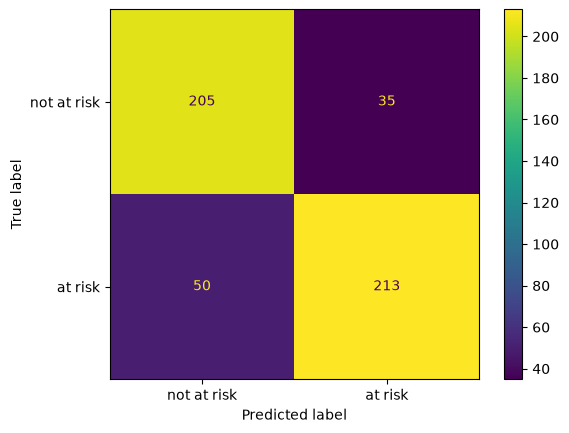

In [ ]:
best_abl_pipe = make_ablation_pipeline(all_meta_num, all_meta_cat, include_text=True)
best_abl_pipe.fit(X_abl.iloc[trainval_idx], y_full[trainval_idx])
y_pred = best_abl_pipe.predict(X_abl.iloc[test_idx])

print(classification_report(y_full[test_idx], y_pred, target_names=['not at risk', 'at risk']))

ConfusionMatrixDisplay.from_predictions(y_full[test_idx], y_pred, display_labels=['not at risk', 'at risk'])
plt.show()


# SRQ3: Model comparison

all three conditions
* text only
* metadata only
* text + metadata

# SRQ3 (Optuna) — SA pool

In [ ]:
def run_optuna_model(model_name, make_objective_fn, make_model_fn,
                     conditions, y_tr, y_te, skf, n_trials=30):

    results = {}
    n_conds = len(conditions)
    for ci, (cond_name, (X_tr, X_te)) in enumerate(conditions.items(), 1):
        print(f"\n  [{model_name}] {cond_name}  (condition {ci}/{n_conds}, {n_trials} trials)",
              flush=True)
        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=42),
        )

        def _cb(study, trial):
            _tqdm.write(
                f"    t{trial.number + 1:>3}/{n_trials}  "
                f"val={trial.value:.4f}  best={study.best_value:.4f}"
            )

        study.optimize(
            lambda trial: make_objective_fn(trial, X_tr, y_tr),
            n_trials=n_trials,
            show_progress_bar=True,
            callbacks=[_cb],
        )
        print(f"  → best: {study.best_params}", flush=True)
        print(f"  → final CV ({skf.get_n_splits()} folds)...", flush=True)
        model = make_model_fn(study.best_params)
        cv = cross_validate(model, X_tr, y_tr, cv=skf,
                            scoring=['average_precision', 'roc_auc'],
                            return_train_score=True)
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X_te)[:, 1]
        test_aucpr = average_precision_score(y_te, y_prob)
        test_auc = roc_auc_score(y_te, y_prob)
        lor = np.log(cv['train_average_precision'].mean() / (test_aucpr + 1e-9))
        cos = (0.5 * cv['train_average_precision'].mean() / (test_aucpr + 1e-9) +
               0.5 * cv['train_average_precision'].std()  / (cv["test_average_precision"].std() + 1e-9))
        results[cond_name] = dict(
            best_params = study.best_params,
            cv_aucpr_mean = cv["test_average_precision"].mean(),
            cv_aucpr_std = cv["test_average_precision"].std(),
            cv_auc_mean = cv["test_roc_auc"].mean(),
            test_aucpr = test_aucpr,
            test_auc = test_auc,

            model = model,
        )
        print(f"CV AUC-PR={study.best_value:.4f}  "
              f"test AUC-PR={test_aucpr:.4f}  test ROC-AUC={test_auc:.4f}  LOR={lor:.4f}")
    return results




def make_xgb_objective(class_ratio, skf):
    def objective(trial, X_tr, y_tr):
        model = XGBClassifier(
            max_depth = trial.suggest_int('max_depth', 3, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            n_estimators = trial.suggest_int('n_estimators', 100, 2000),
            min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
            subsample = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            gamma = trial.suggest_float('gamma', 0.0, 1.0),
            scale_pos_weight = class_ratio,
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', device='cuda', random_state=42, verbosity=0)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='average_precision', n_jobs=1).mean()
    return objective

def make_xgb_model(class_ratio):
    def factory(params):
        return XGBClassifier(
            **{k: params[k] for k in [
                'max_depth','learning_rate','n_estimators','min_child_weight',
                'subsample','colsample_bytree','reg_alpha','reg_lambda','gamma']},
            scale_pos_weight=class_ratio,
            objective='binary:logistic', eval_metric='aucpr',
            tree_method='hist', device='cuda', random_state=42, n_jobs=1, verbosity=0)
    return factory


def make_lgb_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = lgb.LGBMClassifier(
            num_leaves = trial.suggest_int('num_leaves', 20, 300),
            max_depth = trial.suggest_int('max_depth', 3, 10),
            learning_rate  = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            n_estimators = trial.suggest_int('n_estimators', 100, 1500),
            min_child_samples= trial.suggest_int('min_child_samples', 5, 100),
            subsample = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha = trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            reg_lambda = trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            class_weight='balanced', random_state=42, device='gpu', verbose=-1)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                       scoring='average_precision', n_jobs=1).mean()

    return objective

def make_lgb_model():
    def factory(params):
        return lgb.LGBMClassifier(
            **{k: params[k] for k in [
                'num_leaves','max_depth','learning_rate','n_estimators',
                'min_child_samples','subsample','colsample_bytree','reg_alpha','reg_lambda']},
            class_weight='balanced', random_state=42, device='gpu', n_jobs=1, verbose=-1)
    return factory


def make_svc_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = CalibratedClassifierCV(
            LinearSVC(C=trial.suggest_float('C', 1e-3, 1e2, log=True),
                      class_weight='balanced', max_iter=5000))
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_svc_model():
    def factory(params):
        return CalibratedClassifierCV(
            LinearSVC(C=params['C'], class_weight='balanced', max_iter=5000))
    return factory


def make_rf_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = RandomForestClassifier(
            n_estimators = trial.suggest_int('n_estimators', 100, 500),
            max_depth = trial.suggest_int('max_depth', 3, 15),
            min_samples_leaf= trial.suggest_int('min_samples_leaf', 1, 10),
            max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)

        return cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_rf_model():
    def factory(params):
        return RandomForestClassifier(
            **{k: params[k] for k in
               ['n_estimators','max_depth','min_samples_leaf','max_features']},
            class_weight='balanced_subsample', n_jobs=-1, random_state=42)
    return factory


def make_hgb_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = HistGradientBoostingClassifier(
            max_iter = trial.suggest_int('max_iter', 100, 500),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            max_depth = trial.suggest_int('max_depth', 2, 6),
            min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20),
            l2_regularization = trial.suggest_float('l2_regularization', 1e-4, 1.0, log=True),
            class_weight='balanced', random_state=42)

        return cross_val_score(model, X_tr, y_tr, cv=skf,
                               scoring='average_precision', n_jobs=-1).mean()
    return objective

def make_hgb_model():
    def factory(params):
        return HistGradientBoostingClassifier(
            **{k: params[k] for k in
               ['max_iter','learning_rate','max_depth','min_samples_leaf','l2_regularization']},
            class_weight='balanced', random_state=42)
    return factory


def make_catboost_objective(skf):
    def objective(trial, X_tr, y_tr):
        model = CatBoostClassifier(
            depth = trial.suggest_int('depth', 4, 10),
            learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            iterations = trial.suggest_int('iterations', 200, 2000),
            l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1.0, 10.0),
            bagging_temperature= trial.suggest_float('bagging_temperature', 0.0, 1.0),
            random_strength = trial.suggest_float('random_strength', 0.0, 2.0),
            auto_class_weights='Balanced', eval_metric='AUC', task_type='GPU', random_seed=42, verbose=0)
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                       scoring='average_precision', n_jobs=1).mean()
    return objective

def make_catboost_model():
    def factory(params):
        return CatBoostClassifier(
            **{k: params[k] for k in [
                'depth','learning_rate','iterations','l2_leaf_reg',
                'bagging_temperature','random_strength']},
            auto_class_weights='Balanced', eval_metric='AUC', task_type='GPU', random_seed=42, n_jobs=1, verbose=0)
    return factory


ARCH_CHOICES_SKLEARN = [
    (128,), (256,), (512,),
    (256, 128), (512, 256), (512, 128),
    (256, 128, 64), (512, 256, 128),
]

def make_mlp_objective(skf):
    def objective(trial, X_tr, y_tr):
        arch = ARCH_CHOICES_SKLEARN[
            trial.suggest_int('arch_idx', 0, len(ARCH_CHOICES_SKLEARN) - 1)]
        model = MLPClassifier(
            hidden_layer_sizes = arch,
            activation  = 'relu',
            alpha = trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            learning_rate_init = trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
            batch_size = trial.suggest_categorical('batch_size', [64, 128, 256]),
            max_iter=300, early_stopping=True, random_state=42,
        )
        return cross_val_score(model, X_tr, y_tr, cv=skf,
                       scoring='average_precision', n_jobs=1).mean()

    return objective

def make_mlp_model():
    def factory(params):
        arch = ARCH_CHOICES_SKLEARN[params['arch_idx']]
        return MLPClassifier(
            hidden_layer_sizes=arch, activation='relu',
            alpha=params['alpha'],
            learning_rate_init=params['learning_rate_init'],
            batch_size=params['batch_size'],
            max_iter=300, early_stopping=True, random_state=42)
    return factory

print("run_optuna_model and factory functions defined.")

run_optuna_model and factory functions defined.


In [ ]:
_tfidf = TfidfVectorizer(max_features=10_000, ngram_range=(1, 2),
                               sublinear_tf=True, stop_words='english')
_tfidf.fit(df.iloc[trainval_idx]['all_text'])
tfidf_tv = _tfidf.transform(df.iloc[trainval_idx]['all_text']).toarray()
tfidf_te = _tfidf.transform(df.iloc[test_idx]['all_text']).toarray()

meta_tv = meta_all[trainval_idx]; meta_te = meta_all[test_idx]
emb_tv = X_b4_full[trainval_idx]; emb_te  = X_b4_full[test_idx]
b6_tv = X_b6_full[trainval_idx]; b6_te = X_b6_full[test_idx]
y_tv = y_full[trainval_idx]; y_te = y_full[test_idx]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
class_ratio = float((y_tv == 0).sum()) / float((y_tv == 1).sum())
print(f"Class ratio (neg/pos): {class_ratio:.2f}")

conditions = {
    'Text TF-IDF': (tfidf_tv, tfidf_te),
    'Metadata': (meta_tv, meta_te),
    'Text+Meta TF-IDF': (np.hstack([tfidf_tv, meta_tv]), np.hstack([tfidf_te, meta_te])),
    'Text Emb': (emb_tv, emb_te),
    'Text+Meta Emb': (b6_tv, b6_te),
}
catboost_conds = {k: v for k, v in conditions.items()
                        if k in ('Metadata', 'Text+Meta Emb')}
print(f"Conditions: {list(conditions.keys())}")

Class ratio (neg/pos): 0.92
Conditions: ['Text TF-IDF', 'Metadata', 'Text+Meta TF-IDF', 'Text Emb', 'Text+Meta Emb']


#### XGBoost

In [ ]:
xgb = run_optuna_model(
    'XGBoost',
    make_xgb_objective(class_ratio, skf),
    make_xgb_model(class_ratio),
    conditions, y_tv, y_te, skf, n_trials=80)


  [XGBoost] Text TF-IDF  (condition 1/5, 80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8563  best=0.8563
    t  2/80  val=0.8656  best=0.8656
    t  3/80  val=0.9012  best=0.9012
    t  4/80  val=0.8673  best=0.9012
    t  5/80  val=0.8869  best=0.9012
    t  6/80  val=0.8825  best=0.9012
    t  7/80  val=0.8915  best=0.9012
    t  8/80  val=0.8875  best=0.9012
    t  9/80  val=0.8712  best=0.9012
    t 10/80  val=0.8969  best=0.9012
    t 11/80  val=0.8611  best=0.9012
    t 12/80  val=0.8962  best=0.9012
    t 13/80  val=0.9000  best=0.9012
    t 14/80  val=0.9003  best=0.9012
    t 15/80  val=0.8922  best=0.9012
    t 16/80  val=0.9016  best=0.9016
    t 17/80  val=0.9030  best=0.9030
    t 18/80  val=0.9036  best=0.9036
    t 19/80  val=0.9043  best=0.9043
    t 20/80  val=0.9008  best=0.9043
    t 21/80  val=0.9043  best=0.9043
    t 22/80  val=0.9039  best=0.9043
    t 23/80  val=0.8998  best=0.9043
    t 24/80  val=0.9058  best=0.9058
    t 25/80  val=0.9057  best=0.9058
    t 26/80  val=0.9060  best=0.9060
    t 27/80  val=0.9040  best=0.9060
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8183  best=0.8183
    t  2/80  val=0.8403  best=0.8403
    t  3/80  val=0.8474  best=0.8474
    t  4/80  val=0.8082  best=0.8474
    t  5/80  val=0.8432  best=0.8474
    t  6/80  val=0.8434  best=0.8474
    t  7/80  val=0.8257  best=0.8474
    t  8/80  val=0.8269  best=0.8474
    t  9/80  val=0.8341  best=0.8474
    t 10/80  val=0.8522  best=0.8522
    t 11/80  val=0.8393  best=0.8522
    t 12/80  val=0.8462  best=0.8522
    t 13/80  val=0.8556  best=0.8556
    t 14/80  val=0.8583  best=0.8583
    t 15/80  val=0.8578  best=0.8583
    t 16/80  val=0.8525  best=0.8583
    t 17/80  val=0.8510  best=0.8583
    t 18/80  val=0.8482  best=0.8583
    t 19/80  val=0.8571  best=0.8583
    t 20/80  val=0.8616  best=0.8616
    t 21/80  val=0.8572  best=0.8616
    t 22/80  val=0.8648  best=0.8648
    t 23/80  val=0.8633  best=0.8648
    t 24/80  val=0.8586  best=0.8648
    t 25/80  val=0.8565  best=0.8648
    t 26/80  val=0.8606  best=0.8648
    t 27/80  val=0.8508  best=0.8648
 

...

    t  1/80  val=0.8713  best=0.8713
    t  2/80  val=0.8824  best=0.8824
    t  3/80  val=0.9093  best=0.9093
    t  4/80  val=0.8778  best=0.9093
    t  5/80  val=0.8972  best=0.9093
    t  6/80  val=0.8926  best=0.9093
    t  7/80  val=0.8979  best=0.9093
    t  8/80  val=0.8981  best=0.9093
    t  9/80  val=0.8823  best=0.9093
    t 10/80  val=0.9053  best=0.9093
    t 11/80  val=0.8825  best=0.9093
    t 12/80  val=0.9037  best=0.9093
    t 13/80  val=0.9141  best=0.9141
    t 14/80  val=0.9132  best=0.9141
    t 15/80  val=0.9109  best=0.9141
    t 16/80  val=0.9118  best=0.9141
    t 17/80  val=0.9051  best=0.9141
    t 18/80  val=0.9137  best=0.9141
    t 19/80  val=0.9082  best=0.9141
    t 20/80  val=0.9101  best=0.9141
    t 21/80  val=0.9173  best=0.9173
    t 22/80  val=0.9152  best=0.9173
    t 23/80  val=0.9113  best=0.9173
    t 24/80  val=0.9176  best=0.9176
    t 25/80  val=0.9136  best=0.9176
    t 26/80  val=0.9100  best=0.9176
    t 27/80  val=0.9133  best=0.9176
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9118  best=0.9118
    t  2/80  val=0.9195  best=0.9195
    t  3/80  val=0.9215  best=0.9215
    t  4/80  val=0.9094  best=0.9215
    t  5/80  val=0.9213  best=0.9215
    t  6/80  val=0.9194  best=0.9215
    t  7/80  val=0.9028  best=0.9215
    t  8/80  val=0.9139  best=0.9215
    t  9/80  val=0.9103  best=0.9215
    t 10/80  val=0.9184  best=0.9215
    t 11/80  val=0.9170  best=0.9215
    t 12/80  val=0.9224  best=0.9224
    t 13/80  val=0.9206  best=0.9224
    t 14/80  val=0.9163  best=0.9224
    t 15/80  val=0.9218  best=0.9224
    t 16/80  val=0.9224  best=0.9224
    t 17/80  val=0.9205  best=0.9224
    t 18/80  val=0.9198  best=0.9224
    t 19/80  val=0.9224  best=0.9224
    t 20/80  val=0.9177  best=0.9224
    t 21/80  val=0.9181  best=0.9224
    t 22/80  val=0.9214  best=0.9224
    t 23/80  val=0.9209  best=0.9224
    t 24/80  val=0.9208  best=0.9224
    t 25/80  val=0.9222  best=0.9224
    t 26/80  val=0.9193  best=0.9224
    t 27/80  val=0.9190  best=0.9224
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9113  best=0.9113
    t  2/80  val=0.9211  best=0.9211
    t  3/80  val=0.9237  best=0.9237
    t  4/80  val=0.9095  best=0.9237
    t  5/80  val=0.9222  best=0.9237
    t  6/80  val=0.9188  best=0.9237
    t  7/80  val=0.9055  best=0.9237
    t  8/80  val=0.9158  best=0.9237
    t  9/80  val=0.9140  best=0.9237
    t 10/80  val=0.9197  best=0.9237
    t 11/80  val=0.9159  best=0.9237
    t 12/80  val=0.9231  best=0.9237
    t 13/80  val=0.9217  best=0.9237
    t 14/80  val=0.9210  best=0.9237
    t 15/80  val=0.9251  best=0.9251
    t 16/80  val=0.9233  best=0.9251
    t 17/80  val=0.9239  best=0.9251
    t 18/80  val=0.9242  best=0.9251
    t 19/80  val=0.9222  best=0.9251
    t 20/80  val=0.9218  best=0.9251
    t 21/80  val=0.9214  best=0.9251
    t 22/80  val=0.9221  best=0.9251
    t 23/80  val=0.9219  best=0.9251
    t 24/80  val=0.9214  best=0.9251
    t 25/80  val=0.9224  best=0.9251
    t 26/80  val=0.9254  best=0.9254
    t 27/80  val=0.9213  best=0.9254
 

#### LightGBM

In [ ]:
lgb = run_optuna_model(
    'LightGBM',
    make_lgb_objective(skf),
    make_lgb_model(),
    conditions, y_tv, y_te, skf, n_trials=80)


  [LightGBM] Text TF-IDF  (condition 1/5, 80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9078  best=0.9078
    t  2/80  val=0.8835  best=0.9078
    t  3/80  val=0.9009  best=0.9078
    t  4/80  val=0.8928  best=0.9078
    t  5/80  val=0.8942  best=0.9078
    t  6/80  val=0.8958  best=0.9078
    t  7/80  val=0.9114  best=0.9114
    t  8/80  val=0.8661  best=0.9114
    t  9/80  val=0.8596  best=0.9114
    t 10/80  val=0.8918  best=0.9114
    t 11/80  val=0.8773  best=0.9114
    t 12/80  val=0.9025  best=0.9114
    t 13/80  val=0.8906  best=0.9114
    t 14/80  val=0.9118  best=0.9118
    t 15/80  val=0.9111  best=0.9118
    t 16/80  val=0.9119  best=0.9119
    t 17/80  val=0.9094  best=0.9119
    t 18/80  val=0.8963  best=0.9119
    t 19/80  val=0.8754  best=0.9119
    t 20/80  val=0.9040  best=0.9119
    t 21/80  val=0.8666  best=0.9119
    t 22/80  val=0.9096  best=0.9119
    t 23/80  val=0.9061  best=0.9119
    t 24/80  val=0.9144  best=0.9144
    t 25/80  val=0.9069  best=0.9144
    t 26/80  val=0.9059  best=0.9144
    t 27/80  val=0.9066  best=0.9144
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8461  best=0.8461
    t  2/80  val=0.8199  best=0.8461
    t  3/80  val=0.8378  best=0.8461
    t  4/80  val=0.8344  best=0.8461
    t  5/80  val=0.8304  best=0.8461
    t  6/80  val=0.8290  best=0.8461
    t  7/80  val=0.8581  best=0.8581
    t  8/80  val=0.8222  best=0.8581
    t  9/80  val=0.8272  best=0.8581
    t 10/80  val=0.8329  best=0.8581
    t 11/80  val=0.8412  best=0.8581
    t 12/80  val=0.8476  best=0.8581
    t 13/80  val=0.8574  best=0.8581
    t 14/80  val=0.8486  best=0.8581
    t 15/80  val=0.8405  best=0.8581
    t 16/80  val=0.8560  best=0.8581
    t 17/80  val=0.8518  best=0.8581
    t 18/80  val=0.8400  best=0.8581
    t 19/80  val=0.8576  best=0.8581
    t 20/80  val=0.8460  best=0.8581
    t 21/80  val=0.8134  best=0.8581
    t 22/80  val=0.8555  best=0.8581
    t 23/80  val=0.8578  best=0.8581
    t 24/80  val=0.8469  best=0.8581
    t 25/80  val=0.8562  best=0.8581
    t 26/80  val=0.8493  best=0.8581
    t 27/80  val=0.8438  best=0.8581
 

...

    t  1/80  val=0.9150  best=0.9150
    t  2/80  val=0.8896  best=0.9150
    t  3/80  val=0.9081  best=0.9150
    t  4/80  val=0.9038  best=0.9150
    t  5/80  val=0.9012  best=0.9150
    t  6/80  val=0.9048  best=0.9150
    t  7/80  val=0.9211  best=0.9211
    t  8/80  val=0.8827  best=0.9211
    t  9/80  val=0.8812  best=0.9211
    t 10/80  val=0.9037  best=0.9211
    t 11/80  val=0.8928  best=0.9211
    t 12/80  val=0.9155  best=0.9211
    t 13/80  val=0.9231  best=0.9231
    t 14/80  val=0.9121  best=0.9231
    t 15/80  val=0.8998  best=0.9231
    t 16/80  val=0.9216  best=0.9231
    t 17/80  val=0.9082  best=0.9231
    t 18/80  val=0.9206  best=0.9231
    t 19/80  val=0.9039  best=0.9231
    t 20/80  val=0.9092  best=0.9231
    t 21/80  val=0.8832  best=0.9231
    t 22/80  val=0.9177  best=0.9231
    t 23/80  val=0.9169  best=0.9231
    t 24/80  val=0.9162  best=0.9231
    t 25/80  val=0.9124  best=0.9231
    t 26/80  val=0.9127  best=0.9231
    t 27/80  val=0.9082  best=0.9231
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9180  best=0.9180
    t  2/80  val=0.9162  best=0.9180
    t  3/80  val=0.9172  best=0.9180
    t  4/80  val=0.9148  best=0.9180
    t  5/80  val=0.9125  best=0.9180
    t  6/80  val=0.9129  best=0.9180
    t  7/80  val=0.9186  best=0.9186
    t  8/80  val=0.9150  best=0.9186
    t  9/80  val=0.9197  best=0.9197
    t 10/80  val=0.9156  best=0.9197
    t 11/80  val=0.9196  best=0.9197
    t 12/80  val=0.9205  best=0.9205
    t 13/80  val=0.9201  best=0.9205
    t 14/80  val=0.9211  best=0.9211
    t 15/80  val=0.9214  best=0.9214
    t 16/80  val=0.9205  best=0.9214
    t 17/80  val=0.9205  best=0.9214
    t 18/80  val=0.9208  best=0.9214
    t 19/80  val=0.9194  best=0.9214
    t 20/80  val=0.9202  best=0.9214
    t 21/80  val=0.9184  best=0.9214
    t 22/80  val=0.9216  best=0.9216
    t 23/80  val=0.9217  best=0.9217
    t 24/80  val=0.9213  best=0.9217
    t 25/80  val=0.9189  best=0.9217
    t 26/80  val=0.9222  best=0.9222
    t 27/80  val=0.9230  best=0.9230
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9192  best=0.9192
    t  2/80  val=0.9161  best=0.9192
    t  3/80  val=0.9197  best=0.9197
    t  4/80  val=0.9156  best=0.9197
    t  5/80  val=0.9144  best=0.9197
    t  6/80  val=0.9160  best=0.9197
    t  7/80  val=0.9211  best=0.9211
    t  8/80  val=0.9178  best=0.9211
    t  9/80  val=0.9215  best=0.9215
    t 10/80  val=0.9170  best=0.9215
    t 11/80  val=0.9217  best=0.9217
    t 12/80  val=0.9227  best=0.9227
    t 13/80  val=0.9212  best=0.9227
    t 14/80  val=0.9218  best=0.9227
    t 15/80  val=0.9221  best=0.9227
    t 16/80  val=0.9223  best=0.9227
    t 17/80  val=0.9220  best=0.9227
    t 18/80  val=0.9220  best=0.9227
    t 19/80  val=0.9229  best=0.9229
    t 20/80  val=0.9226  best=0.9229
    t 21/80  val=0.9256  best=0.9256
    t 22/80  val=0.9236  best=0.9256
    t 23/80  val=0.9228  best=0.9256
    t 24/80  val=0.9244  best=0.9256
    t 25/80  val=0.9225  best=0.9256
    t 26/80  val=0.9210  best=0.9256
    t 27/80  val=0.9219  best=0.9256
 

#### LinearSVC

In [ ]:
svc = run_optuna_model(
    'LinearSVC',
    make_svc_objective(skf),
    make_svc_model(),
    conditions, y_tv, y_te, skf, n_trials=80)


  [LinearSVC] Text TF-IDF  (condition 1/5, 80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9030  best=0.9030
    t  2/80  val=0.9022  best=0.9030
    t  3/80  val=0.9170  best=0.9170
    t  4/80  val=0.9235  best=0.9235
    t  5/80  val=0.8684  best=0.9235
    t  6/80  val=0.8684  best=0.9235
    t  7/80  val=0.8574  best=0.9235
    t  8/80  val=0.9085  best=0.9235
    t  9/80  val=0.9234  best=0.9235
    t 10/80  val=0.9186  best=0.9235
    t 11/80  val=0.9187  best=0.9235
    t 12/80  val=0.9206  best=0.9235
    t 13/80  val=0.9237  best=0.9237
    t 14/80  val=0.8972  best=0.9237
    t 15/80  val=0.9181  best=0.9237
    t 16/80  val=0.9238  best=0.9238
    t 17/80  val=0.8960  best=0.9238
    t 18/80  val=0.9111  best=0.9238
    t 19/80  val=0.9237  best=0.9238
    t 20/80  val=0.9131  best=0.9238
    t 21/80  val=0.8870  best=0.9238
    t 22/80  val=0.9236  best=0.9238
    t 23/80  val=0.9237  best=0.9238
    t 24/80  val=0.9214  best=0.9238
    t 25/80  val=0.9205  best=0.9238
    t 26/80  val=0.9121  best=0.9238
    t 27/80  val=0.9227  best=0.9238
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.7224  best=0.7224
    t  2/80  val=0.7238  best=0.7238
    t  3/80  val=0.7241  best=0.7241
    t  4/80  val=0.7241  best=0.7241
    t  5/80  val=0.7178  best=0.7241
    t  6/80  val=0.7178  best=0.7241
    t  7/80  val=0.7147  best=0.7241
    t  8/80  val=0.7238  best=0.7241
    t  9/80  val=0.7240  best=0.7241
    t 10/80  val=0.7241  best=0.7241
    t 11/80  val=0.7223  best=0.7241
    t 12/80  val=0.7238  best=0.7241
    t 13/80  val=0.7241  best=0.7241
    t 14/80  val=0.7231  best=0.7241
    t 15/80  val=0.7238  best=0.7241
    t 16/80  val=0.7239  best=0.7241
    t 17/80  val=0.7240  best=0.7241
    t 18/80  val=0.7238  best=0.7241
    t 19/80  val=0.7225  best=0.7241
    t 20/80  val=0.7242  best=0.7242
    t 21/80  val=0.7241  best=0.7242
    t 22/80  val=0.7241  best=0.7242
    t 23/80  val=0.7240  best=0.7242
    t 24/80  val=0.7238  best=0.7242
    t 25/80  val=0.7242  best=0.7242
    t 26/80  val=0.7238  best=0.7242
    t 27/80  val=0.7240  best=0.7242
 

...

    t  1/80  val=0.8830  best=0.8830
    t  2/80  val=0.8575  best=0.8830
    t  3/80  val=0.8822  best=0.8830
    t  4/80  val=0.8978  best=0.8978
    t  5/80  val=0.8434  best=0.8978
    t  6/80  val=0.8434  best=0.8978
    t  7/80  val=0.8341  best=0.8978
    t  8/80  val=0.8657  best=0.8978
    t  9/80  val=0.8978  best=0.8978
    t 10/80  val=0.8858  best=0.8978
    t 11/80  val=0.8962  best=0.8978
    t 12/80  val=0.8978  best=0.8978
    t 13/80  val=0.8892  best=0.8978
    t 14/80  val=0.8988  best=0.8988
    t 15/80  val=0.8646  best=0.8988
    t 16/80  val=0.8988  best=0.8988
    t 17/80  val=0.8787  best=0.8988
    t 18/80  val=0.8986  best=0.8988
    t 19/80  val=0.8756  best=0.8988
    t 20/80  val=0.8586  best=0.8988
    t 21/80  val=0.8948  best=0.8988
    t 22/80  val=0.8979  best=0.8988
    t 23/80  val=0.8986  best=0.8988
    t 24/80  val=0.8936  best=0.8988
    t 25/80  val=0.8717  best=0.8988
    t 26/80  val=0.8931  best=0.8988
    t 27/80  val=0.8988  best=0.8988
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8791  best=0.8791
    t  2/80  val=0.8570  best=0.8791
    t  3/80  val=0.8794  best=0.8794
    t  4/80  val=0.8957  best=0.8957
    t  5/80  val=0.8060  best=0.8957
    t  6/80  val=0.8060  best=0.8957
    t  7/80  val=0.7648  best=0.8957
    t  8/80  val=0.8627  best=0.8957
    t  9/80  val=0.8955  best=0.8957
    t 10/80  val=0.8828  best=0.8957
    t 11/80  val=0.8922  best=0.8957
    t 12/80  val=0.8938  best=0.8957
    t 13/80  val=0.8960  best=0.8960
    t 14/80  val=0.8731  best=0.8960
    t 15/80  val=0.8821  best=0.8960
    t 16/80  val=0.8963  best=0.8963
    t 17/80  val=0.8713  best=0.8963
    t 18/80  val=0.8672  best=0.8963
    t 19/80  val=0.8963  best=0.8963
    t 20/80  val=0.8868  best=0.8963
    t 21/80  val=0.8563  best=0.8963
    t 22/80  val=0.8960  best=0.8963
    t 23/80  val=0.8951  best=0.8963
    t 24/80  val=0.8900  best=0.8963
    t 25/80  val=0.8954  best=0.8963
    t 26/80  val=0.8685  best=0.8963
    t 27/80  val=0.8938  best=0.8963
 

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  w

  ✓ CV AUC-PR=0.8964  test AUC-PR=0.8868  test ROC-AUC=0.9036  LOR=0.0905


#### RandomForest

In [ ]:
rf = run_optuna_model(
    'RandomForest',
    make_rf_objective(skf),
    make_rf_model(),
    conditions, y_tv, y_te, skf, n_trials=80)


  [RandomForest] Text TF-IDF  (condition 1/5, 80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8927  best=0.8927
    t  2/80  val=0.8266  best=0.8927
    t  3/80  val=0.8905  best=0.8927
    t  4/80  val=0.8767  best=0.8927
    t  5/80  val=0.8558  best=0.8927
    t  6/80  val=0.8710  best=0.8927
    t  7/80  val=0.8677  best=0.8927
    t  8/80  val=0.8816  best=0.8927
    t  9/80  val=0.8916  best=0.8927
    t 10/80  val=0.8803  best=0.8927
    t 11/80  val=0.8658  best=0.8927
    t 12/80  val=0.8925  best=0.8927
    t 13/80  val=0.8940  best=0.8940
    t 14/80  val=0.8907  best=0.8940
    t 15/80  val=0.8954  best=0.8954
    t 16/80  val=0.8936  best=0.8954
    t 17/80  val=0.8927  best=0.8954
    t 18/80  val=0.8962  best=0.8962
    t 19/80  val=0.8885  best=0.8962
    t 20/80  val=0.8869  best=0.8962
    t 21/80  val=0.9006  best=0.9006
    t 22/80  val=0.9008  best=0.9008
    t 23/80  val=0.9008  best=0.9008
    t 24/80  val=0.9006  best=0.9008
    t 25/80  val=0.9015  best=0.9015
    t 26/80  val=0.9016  best=0.9016
    t 27/80  val=0.8933  best=0.9016
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8452  best=0.8452
    t  2/80  val=0.7740  best=0.8452
    t  3/80  val=0.8405  best=0.8452
    t  4/80  val=0.8182  best=0.8452
    t  5/80  val=0.7950  best=0.8452
    t  6/80  val=0.8115  best=0.8452
    t  7/80  val=0.8131  best=0.8452
    t  8/80  val=0.8258  best=0.8452
    t  9/80  val=0.8502  best=0.8502
    t 10/80  val=0.8265  best=0.8502
    t 11/80  val=0.8492  best=0.8502
    t 12/80  val=0.8530  best=0.8530
    t 13/80  val=0.8530  best=0.8530
    t 14/80  val=0.8586  best=0.8586
    t 15/80  val=0.8532  best=0.8586
    t 16/80  val=0.8517  best=0.8586
    t 17/80  val=0.8536  best=0.8586
    t 18/80  val=0.8638  best=0.8638
    t 19/80  val=0.8644  best=0.8644
    t 20/80  val=0.8637  best=0.8644
    t 21/80  val=0.8679  best=0.8679
    t 22/80  val=0.8637  best=0.8679
    t 23/80  val=0.8644  best=0.8679
    t 24/80  val=0.8603  best=0.8679
    t 25/80  val=0.8638  best=0.8679
    t 26/80  val=0.8634  best=0.8679
    t 27/80  val=0.8425  best=0.8679
 

...

    t  1/80  val=0.8947  best=0.8947
    t  2/80  val=0.8360  best=0.8947
    t  3/80  val=0.8931  best=0.8947
    t  4/80  val=0.8774  best=0.8947
    t  5/80  val=0.8588  best=0.8947
    t  6/80  val=0.8710  best=0.8947
    t  7/80  val=0.8696  best=0.8947
    t  8/80  val=0.8808  best=0.8947
    t  9/80  val=0.8952  best=0.8952
    t 10/80  val=0.8809  best=0.8952
    t 11/80  val=0.8814  best=0.8952
    t 12/80  val=0.8915  best=0.8952
    t 13/80  val=0.8963  best=0.8963
    t 14/80  val=0.8955  best=0.8963
    t 15/80  val=0.8975  best=0.8975
    t 16/80  val=0.8964  best=0.8975
    t 17/80  val=0.9001  best=0.9001
    t 18/80  val=0.9025  best=0.9025
    t 19/80  val=0.8891  best=0.9025
    t 20/80  val=0.8887  best=0.9025
    t 21/80  val=0.9042  best=0.9042
    t 22/80  val=0.9040  best=0.9042
    t 23/80  val=0.9041  best=0.9042
    t 24/80  val=0.9044  best=0.9044
    t 25/80  val=0.9062  best=0.9062
    t 26/80  val=0.9053  best=0.9062
    t 27/80  val=0.8919  best=0.9062
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9123  best=0.9123
    t  2/80  val=0.8643  best=0.9123
    t  3/80  val=0.9088  best=0.9123
    t  4/80  val=0.8991  best=0.9123
    t  5/80  val=0.8797  best=0.9123
    t  6/80  val=0.8951  best=0.9123
    t  7/80  val=0.8900  best=0.9123
    t  8/80  val=0.9052  best=0.9123
    t  9/80  val=0.9128  best=0.9128
    t 10/80  val=0.9082  best=0.9128
    t 11/80  val=0.9112  best=0.9128
    t 12/80  val=0.9095  best=0.9128
    t 13/80  val=0.9157  best=0.9157
    t 14/80  val=0.9152  best=0.9157
    t 15/80  val=0.9158  best=0.9158
    t 16/80  val=0.9153  best=0.9158
    t 17/80  val=0.9168  best=0.9168
    t 18/80  val=0.9182  best=0.9182
    t 19/80  val=0.9152  best=0.9182
    t 20/80  val=0.9131  best=0.9182
    t 21/80  val=0.9173  best=0.9182
    t 22/80  val=0.9174  best=0.9182
    t 23/80  val=0.9174  best=0.9182
    t 24/80  val=0.9174  best=0.9182
    t 25/80  val=0.9164  best=0.9182
    t 26/80  val=0.9151  best=0.9182
    t 27/80  val=0.9080  best=0.9182
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9122  best=0.9122
    t  2/80  val=0.8683  best=0.9122
    t  3/80  val=0.9100  best=0.9122
    t  4/80  val=0.9030  best=0.9122
    t  5/80  val=0.8797  best=0.9122
    t  6/80  val=0.8937  best=0.9122
    t  7/80  val=0.8914  best=0.9122
    t  8/80  val=0.9048  best=0.9122
    t  9/80  val=0.9163  best=0.9163
    t 10/80  val=0.9085  best=0.9163
    t 11/80  val=0.9115  best=0.9163
    t 12/80  val=0.9096  best=0.9163
    t 13/80  val=0.9162  best=0.9163
    t 14/80  val=0.9160  best=0.9163
    t 15/80  val=0.9129  best=0.9163
    t 16/80  val=0.9177  best=0.9177
    t 17/80  val=0.9128  best=0.9177
    t 18/80  val=0.9177  best=0.9177
    t 19/80  val=0.9142  best=0.9177
    t 20/80  val=0.9168  best=0.9177
    t 21/80  val=0.9138  best=0.9177
    t 22/80  val=0.9182  best=0.9182
    t 23/80  val=0.9181  best=0.9182
    t 24/80  val=0.9164  best=0.9182
    t 25/80  val=0.9163  best=0.9182
    t 26/80  val=0.9179  best=0.9182
    t 27/80  val=0.9150  best=0.9182
 

#### HistGradBoost

In [ ]:
hgb = run_optuna_model(
    'HistGradBoost',
    make_hgb_objective(skf),
    make_hgb_model(),
    conditions, y_tv, y_te, skf, n_trials=80)


  [HistGradBoost] Text TF-IDF  (condition 1/5, 80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8938  best=0.8938
    t  2/80  val=0.8968  best=0.8968
    t  3/80  val=0.9085  best=0.9085
    t  4/80  val=0.8966  best=0.9085
    t  5/80  val=0.8883  best=0.9085
    t  6/80  val=0.8943  best=0.9085
    t  7/80  val=0.8745  best=0.9085
    t  8/80  val=0.8818  best=0.9085
    t  9/80  val=0.8788  best=0.9085
    t 10/80  val=0.8964  best=0.9085
    t 11/80  val=0.9019  best=0.9085
    t 12/80  val=0.9014  best=0.9085
    t 13/80  val=0.8990  best=0.9085
    t 14/80  val=0.9083  best=0.9085
    t 15/80  val=0.9059  best=0.9085
    t 16/80  val=0.9104  best=0.9104
    t 17/80  val=0.9063  best=0.9104
    t 18/80  val=0.9133  best=0.9133
    t 19/80  val=0.9025  best=0.9133
    t 20/80  val=0.9006  best=0.9133
    t 21/80  val=0.9091  best=0.9133
    t 22/80  val=0.9097  best=0.9133
    t 23/80  val=0.9099  best=0.9133
    t 24/80  val=0.9036  best=0.9133
    t 25/80  val=0.9060  best=0.9133
    t 26/80  val=0.9094  best=0.9133
    t 27/80  val=0.8968  best=0.9133
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8371  best=0.8371
    t  2/80  val=0.8424  best=0.8424
    t  3/80  val=0.8456  best=0.8456
    t  4/80  val=0.8330  best=0.8456
    t  5/80  val=0.8255  best=0.8456
    t  6/80  val=0.8426  best=0.8456
    t  7/80  val=0.8009  best=0.8456
    t  8/80  val=0.8235  best=0.8456
    t  9/80  val=0.8104  best=0.8456
    t 10/80  val=0.8448  best=0.8456
    t 11/80  val=0.8534  best=0.8534
    t 12/80  val=0.8470  best=0.8534
    t 13/80  val=0.8472  best=0.8534
    t 14/80  val=0.8483  best=0.8534
    t 15/80  val=0.8429  best=0.8534
    t 16/80  val=0.8477  best=0.8534
    t 17/80  val=0.8438  best=0.8534
    t 18/80  val=0.8440  best=0.8534
    t 19/80  val=0.8496  best=0.8534
    t 20/80  val=0.8487  best=0.8534
    t 21/80  val=0.8509  best=0.8534
    t 22/80  val=0.8493  best=0.8534
    t 23/80  val=0.8403  best=0.8534
    t 24/80  val=0.8399  best=0.8534
    t 25/80  val=0.8471  best=0.8534
    t 26/80  val=0.8514  best=0.8534
    t 27/80  val=0.8458  best=0.8534
 

...

    t  1/80  val=0.9029  best=0.9029
    t  2/80  val=0.9024  best=0.9029
    t  3/80  val=0.9123  best=0.9123
    t  4/80  val=0.9013  best=0.9123
    t  5/80  val=0.8935  best=0.9123
    t  6/80  val=0.9026  best=0.9123
    t  7/80  val=0.8833  best=0.9123
    t  8/80  val=0.8893  best=0.9123
    t  9/80  val=0.8857  best=0.9123
    t 10/80  val=0.9040  best=0.9123
    t 11/80  val=0.9110  best=0.9123
    t 12/80  val=0.9078  best=0.9123
    t 13/80  val=0.9074  best=0.9123
    t 14/80  val=0.9096  best=0.9123
    t 15/80  val=0.9121  best=0.9123
    t 16/80  val=0.9128  best=0.9128
    t 17/80  val=0.9146  best=0.9146
    t 18/80  val=0.9096  best=0.9146
    t 19/80  val=0.9128  best=0.9146
    t 20/80  val=0.9009  best=0.9146
    t 21/80  val=0.9104  best=0.9146
    t 22/80  val=0.9078  best=0.9146
    t 23/80  val=0.9056  best=0.9146
    t 24/80  val=0.9047  best=0.9146
    t 25/80  val=0.9105  best=0.9146
    t 26/80  val=0.9109  best=0.9146
    t 27/80  val=0.9065  best=0.9146
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9223  best=0.9223
    t  2/80  val=0.9051  best=0.9223
    t  3/80  val=0.9193  best=0.9223
    t  4/80  val=0.9079  best=0.9223
    t  5/80  val=0.9008  best=0.9223
    t  6/80  val=0.9134  best=0.9223
    t  7/80  val=0.8881  best=0.9223
    t  8/80  val=0.9003  best=0.9223
    t  9/80  val=0.8951  best=0.9223
    t 10/80  val=0.9150  best=0.9223
    t 11/80  val=0.9175  best=0.9223
    t 12/80  val=0.9135  best=0.9223
    t 13/80  val=0.9141  best=0.9223
    t 14/80  val=0.9175  best=0.9223
    t 15/80  val=0.9198  best=0.9223
    t 16/80  val=0.9165  best=0.9223
    t 17/80  val=0.9224  best=0.9224
    t 18/80  val=0.9234  best=0.9234
    t 19/80  val=0.9201  best=0.9234
    t 20/80  val=0.9189  best=0.9234
    t 21/80  val=0.9125  best=0.9234
    t 22/80  val=0.9222  best=0.9234
    t 23/80  val=0.9204  best=0.9234
    t 24/80  val=0.9196  best=0.9234
    t 25/80  val=0.9200  best=0.9234
    t 26/80  val=0.9196  best=0.9234
    t 27/80  val=0.9199  best=0.9234
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9195  best=0.9195
    t  2/80  val=0.9071  best=0.9195
    t  3/80  val=0.9155  best=0.9195
    t  4/80  val=0.9089  best=0.9195
    t  5/80  val=0.9035  best=0.9195
    t  6/80  val=0.9148  best=0.9195
    t  7/80  val=0.8903  best=0.9195
    t  8/80  val=0.9029  best=0.9195
    t  9/80  val=0.8968  best=0.9195
    t 10/80  val=0.9172  best=0.9195
    t 11/80  val=0.9237  best=0.9237
    t 12/80  val=0.9205  best=0.9237
    t 13/80  val=0.9214  best=0.9237
    t 14/80  val=0.9225  best=0.9237
    t 15/80  val=0.9199  best=0.9237
    t 16/80  val=0.9237  best=0.9237
    t 17/80  val=0.9201  best=0.9237
    t 18/80  val=0.9213  best=0.9237
    t 19/80  val=0.9256  best=0.9256
    t 20/80  val=0.9250  best=0.9256
    t 21/80  val=0.9221  best=0.9256
    t 22/80  val=0.9230  best=0.9256
    t 23/80  val=0.9236  best=0.9256
    t 24/80  val=0.9241  best=0.9256
    t 25/80  val=0.9241  best=0.9256
    t 26/80  val=0.9218  best=0.9256
    t 27/80  val=0.9246  best=0.9256
 

#### CatBoost
metadata + text+metadata emb only

In [ ]:
catboost = run_optuna_model(
    'CatBoost',
    make_catboost_objective(skf),
    make_catboost_model(),
    catboost_conds, y_tv, y_te, skf, n_trials=100)


  [CatBoost] Metadata  (condition 1/2, 100 trials)


  0%|          | 0/100 [00:00<?, ?it/s]

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


    t  1/100  val=0.8411  best=0.8411


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


...

Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


    t 21/100  val=0.8659  best=0.8659


Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU
Default metric period is 5 because AUC is/are not implemented for GPU


[W 2026-06-25 07:26:06,828] Trial 21 failed with parameters: {'depth': 10, 'learning_rate': 0.01590655174610217, 'iterations': 1578, 'l2_leaf_reg': 3.2422213926205616, 'bagging_temperature': 0.8478889699549474, 'random_strength': 1.2060662822810368} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_2946/1527975156.py", line 21, in <lambda>
    lambda trial: make_objective_fn(trial, X_tr, y_tr),
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2946/1527975156.py", line 188, in objective
    return cross_val_score(model, X_tr, y_tr, cv=skf,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
  

KeyboardInterrupt: 

#### MLP

In [ ]:
mlp = run_optuna_model(
    'MLP',
    make_mlp_objective(skf),
    make_mlp_model(),
    conditions, y_tv, y_te, skf, n_trials=80)


  [MLP] Text TF-IDF  (condition 1/5, 80 trials)


  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9092  best=0.9092
    t  2/80  val=0.9207  best=0.9207
    t  3/80  val=0.9083  best=0.9207
    t  4/80  val=0.9139  best=0.9207
    t  5/80  val=0.9167  best=0.9207
    t  6/80  val=0.9088  best=0.9207
    t  7/80  val=0.9134  best=0.9207
    t  8/80  val=0.9128  best=0.9207
    t  9/80  val=0.9170  best=0.9207
    t 10/80  val=0.9134  best=0.9207
    t 11/80  val=0.9161  best=0.9207
    t 12/80  val=0.9153  best=0.9207
    t 13/80  val=0.9106  best=0.9207
    t 14/80  val=0.9163  best=0.9207
    t 15/80  val=0.9138  best=0.9207
    t 16/80  val=0.9008  best=0.9207
    t 17/80  val=0.9129  best=0.9207
    t 18/80  val=0.9161  best=0.9207
    t 19/80  val=0.9128  best=0.9207
    t 20/80  val=0.9223  best=0.9223
    t 21/80  val=0.9147  best=0.9223
    t 22/80  val=0.9212  best=0.9223
    t 23/80  val=0.9215  best=0.9223
    t 24/80  val=0.9160  best=0.9223
    t 25/80  val=0.9237  best=0.9237
    t 26/80  val=0.9236  best=0.9237
    t 27/80  val=0.9232  best=0.9237
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.7920  best=0.7920
    t  2/80  val=0.7692  best=0.7920
    t  3/80  val=0.7539  best=0.7920
    t  4/80  val=0.8104  best=0.8104
    t  5/80  val=0.7861  best=0.8104
    t  6/80  val=0.7735  best=0.8104
    t  7/80  val=0.7905  best=0.8104
    t  8/80  val=0.7432  best=0.8104
    t  9/80  val=0.8066  best=0.8104
    t 10/80  val=0.7643  best=0.8104
    t 11/80  val=0.7845  best=0.8104
    t 12/80  val=0.7994  best=0.8104
    t 13/80  val=0.7936  best=0.8104
    t 14/80  val=0.8006  best=0.8104
    t 15/80  val=0.8100  best=0.8104
    t 16/80  val=0.7796  best=0.8104
    t 17/80  val=0.8130  best=0.8130
    t 18/80  val=0.8129  best=0.8130
    t 19/80  val=0.7948  best=0.8130
    t 20/80  val=0.7704  best=0.8130
    t 21/80  val=0.7993  best=0.8130
    t 22/80  val=0.8021  best=0.8130
    t 23/80  val=0.8102  best=0.8130
    t 24/80  val=0.7970  best=0.8130
    t 25/80  val=0.7691  best=0.8130
    t 26/80  val=0.8123  best=0.8130
    t 27/80  val=0.8162  best=0.8162
 

...

    t  1/80  val=0.9111  best=0.9111
    t  2/80  val=0.9256  best=0.9256
    t  3/80  val=0.9282  best=0.9282
    t  4/80  val=0.9180  best=0.9282
    t  5/80  val=0.9233  best=0.9282
    t  6/80  val=0.9271  best=0.9282
    t  7/80  val=0.9243  best=0.9282
    t  8/80  val=0.9172  best=0.9282
    t  9/80  val=0.9121  best=0.9282
    t 10/80  val=0.9256  best=0.9282
    t 11/80  val=0.9258  best=0.9282
    t 12/80  val=0.9297  best=0.9297
    t 13/80  val=0.9299  best=0.9299
    t 14/80  val=0.9299  best=0.9299
    t 15/80  val=0.9253  best=0.9299
    t 16/80  val=0.9296  best=0.9299
    t 17/80  val=0.9260  best=0.9299
    t 18/80  val=0.9273  best=0.9299
    t 19/80  val=0.9233  best=0.9299
    t 20/80  val=0.9209  best=0.9299
    t 21/80  val=0.9276  best=0.9299
    t 22/80  val=0.9295  best=0.9299
    t 23/80  val=0.9288  best=0.9299
    t 24/80  val=0.9229  best=0.9299
    t 25/80  val=0.9272  best=0.9299
    t 26/80  val=0.9273  best=0.9299
    t 27/80  val=0.9282  best=0.9299
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.8945  best=0.8945
    t  2/80  val=0.8725  best=0.8945
    t  3/80  val=0.8853  best=0.8945
    t  4/80  val=0.8861  best=0.8945
    t  5/80  val=0.8925  best=0.8945
    t  6/80  val=0.9018  best=0.9018
    t  7/80  val=0.8929  best=0.9018
    t  8/80  val=0.8937  best=0.9018
    t  9/80  val=0.9049  best=0.9049
    t 10/80  val=0.8841  best=0.9049
    t 11/80  val=0.8951  best=0.9049
    t 12/80  val=0.8983  best=0.9049
    t 13/80  val=0.8949  best=0.9049
    t 14/80  val=0.8998  best=0.9049
    t 15/80  val=0.8937  best=0.9049
    t 16/80  val=0.8972  best=0.9049
    t 17/80  val=0.8951  best=0.9049
    t 18/80  val=0.8980  best=0.9049
    t 19/80  val=0.9003  best=0.9049
    t 20/80  val=0.8942  best=0.9049
    t 21/80  val=0.8770  best=0.9049
    t 22/80  val=0.8927  best=0.9049
    t 23/80  val=0.9018  best=0.9049
    t 24/80  val=0.9050  best=0.9050
    t 25/80  val=0.9015  best=0.9050
    t 26/80  val=0.8965  best=0.9050
    t 27/80  val=0.9023  best=0.9050
 

  0%|          | 0/80 [00:00<?, ?it/s]

    t  1/80  val=0.9036  best=0.9036
    t  2/80  val=0.8997  best=0.9036
    t  3/80  val=0.9074  best=0.9074
    t  4/80  val=0.9117  best=0.9117
    t  5/80  val=0.9031  best=0.9117
    t  6/80  val=0.9049  best=0.9117
    t  7/80  val=0.9086  best=0.9117
    t  8/80  val=0.8923  best=0.9117
    t  9/80  val=0.9069  best=0.9117
    t 10/80  val=0.8996  best=0.9117
    t 11/80  val=0.9128  best=0.9128
    t 12/80  val=0.9102  best=0.9128
    t 13/80  val=0.9031  best=0.9128
    t 14/80  val=0.9116  best=0.9128
    t 15/80  val=0.9108  best=0.9128
    t 16/80  val=0.9052  best=0.9128
    t 17/80  val=0.9098  best=0.9128
    t 18/80  val=0.9090  best=0.9128
    t 19/80  val=0.8988  best=0.9128
    t 20/80  val=0.9023  best=0.9128
    t 21/80  val=0.9062  best=0.9128
    t 22/80  val=0.9108  best=0.9128
    t 23/80  val=0.9120  best=0.9128
    t 24/80  val=0.9047  best=0.9128
    t 25/80  val=0.9057  best=0.9128
    t 26/80  val=0.9054  best=0.9128
    t 27/80  val=0.9100  best=0.9128
 

In [ ]:
all_optuna = {
    'XGBoost': xgb,
    'LightGBM': lgb,
    'LinearSVC': svc,
    'RandomForest': rf,
    'HistGradBoost': hgb,
    # 'CatBoost': catboost,
    'MLP': mlp,
}

sa_rows = []
for model_name, cond_dict in all_optuna.items():
    for cond_name, r in cond_dict.items():
        sa_rows.append({
            'model': model_name,
            'condition': cond_name,
            'cv_aucpr': f"{r['cv_aucpr_mean']:.4f} ± {r['cv_aucpr_std']:.4f}",
            'cv_auc': f"{r['cv_auc_mean']:.4f}",
            'test_aucpr': round(r['test_aucpr'], 4),
            'test_auc': round(r['test_auc'], 4),
            # 'LOR': round(r['lor'], 4),
            # 'COS': round(r['cos'], 4),
        })

df_optuna = pd.DataFrame(sa_rows)

In [ ]:
pivot_bo_aucpr = df_optuna.pivot_table(
    index='model', columns='condition', values='test_aucpr', aggfunc='first'
).round(4).sort_values('Text+Meta Emb', ascending=False)

display(pivot_bo_aucpr)

condition,Metadata,Text Emb,Text TF-IDF,Text+Meta Emb,Text+Meta TF-IDF
model,,,,,
LightGBM,0.8823,0.9312,0.9371,0.9459,0.9457
XGBoost,0.8824,0.9371,0.9284,0.9385,0.9453
HistGradBoost,0.8709,0.9307,0.9304,0.9381,0.9377
RandomForest,0.8797,0.9241,0.9161,0.9215,0.9262
MLP,0.8094,0.9125,0.9328,0.9007,0.9278
LinearSVC,0.7163,0.9006,0.9348,0.8868,0.9175


In [ ]:
pivot_bo_auc = df_optuna.pivot_table(
    index='model', columns='condition', values='test_auc', aggfunc='first'
).round(4).loc[pivot_bo_aucpr.index]

display(pivot_bo_auc)


condition,Metadata,Text Emb,Text TF-IDF,Text+Meta Emb,Text+Meta TF-IDF
model,,,,,
LightGBM,0.8672,0.9216,0.9253,0.9370,0.9371
XGBoost,0.8687,0.9276,0.9155,0.9317,0.9353
HistGradBoost,0.8585,0.9256,0.9200,0.9322,0.9359
RandomForest,0.8719,0.9061,0.9012,0.9080,0.9160
MLP,0.8150,0.9106,0.9257,0.9107,0.9355
LinearSVC,0.7183,0.8973,0.9248,0.9036,0.9248


In [ ]:
display(df_optuna.sort_values(['condition', 'test_aucpr'], ascending=[True, False]))

,model,condition,cv_aucpr,cv_auc,test_aucpr,test_auc
1,XGBoost,Metadata,0.8657 ± 0.0201,0.8562,0.8824,0.8687
6,LightGBM,Metadata,0.8632 ± 0.0196,0.8529,0.8823,0.8672
16,RandomForest,Metadata,0.8683 ± 0.0206,0.8597,0.8797,0.8719
21,HistGradBoost,Metadata,0.8554 ± 0.0260,0.8475,0.8709,0.8585
26,MLP,Metadata,0.8235 ± 0.0291,0.8170,0.8094,0.8150
11,LinearSVC,Metadata,0.7242 ± 0.0287,0.7004,0.7163,0.7183
3,XGBoost,Text Emb,0.9245 ± 0.0169,0.9122,0.9371,0.9276
8,LightGBM,Text Emb,0.9242 ± 0.0158,0.9114,0.9312,0.9216
23,HistGradBoost,Text Emb,0.9249 ± 0.0133,0.9109,0.9307,0.9256
18,RandomForest,Text Emb,0.9188 ± 0.0172,0.9055,0.9241,0.9061


# Evaluation

In [ ]:
per-feature auc because why is the performance so high

In [25]:
investigate = flagged_cols + text_prop_cols + engagement_cols + completeness_cols + temporal_cols

rows = []
for col in investigate:
    vals = df[col].fillna(0).values.astype(float)
    if vals.std() == 0:
        rows.append({'feature': col, 'auc': 0.5, 'mean_c0': vals[y_full==0].mean(), 'mean_c1': vals[y_full==1].mean()})
        continue
    auc = _auc(y_full, vals)
    auc = max(auc, 1 - auc)  # flip if inverted predictor
    rows.append({
        'feature': col,
        'auc': round(auc, 4),
        'mean_c0': round(vals[y_full == 0].mean(), 4),
        'mean_c1': round(vals[y_full == 1].mean(), 4),
    })

feat_df = pd.DataFrame(rows).sort_values('auc', ascending=False)
print(feat_df.to_string(index=False))

print('\nFeatures with AUC > 0.75 (likely driving inflation)')
print(feat_df[feat_df['auc'] > 0.75].to_string(index=False))


                   feature    auc  mean_c0  mean_c1
          has_landing_page 0.6197   0.5054   0.7449
               desc_length 0.5935 694.1715 997.2803
           desc_word_count 0.5899  99.6095 140.9673
                n_keywords 0.5769   7.6603   7.3747
               has_license 0.5580   0.7194   0.8355
unique_flagged_words_total 0.5526   0.5912   0.9520
              title_length 0.5436  60.2731  61.7966
    has_flagged_word_total 0.5414   0.3139   0.3968
             flagged_ratio 0.5389   0.0078   0.0148
 total_flagged_terms_total 0.5376   0.8351   1.0990
  total_nyt_terms_abstract 0.5326   0.3447   0.4532
  total_pen_terms_abstract 0.5294   0.4763   0.6062
            avg_repetition 0.5272   0.4230   0.4539
                popularity 0.5256   9.4213  16.9977
           has_periodicity 0.5090   0.1940   0.1759
          org_type_federal 0.5042   0.9808   0.9893

Features with AUC > 0.75 (likely driving inflation)
Empty DataFrame
Columns: [feature, auc, mean_c0, mean_c1]
Index

looking at suspicious features

In [26]:
sus = [
    'has_landing_page',
    'desc_length',
    'n_keywords',
    'desc_length',
    'has_license',
]

In [27]:
for col in sus:
    c0 = df.loc[y_full == 0, col]
    c1 = df.loc[y_full == 1, col]
    nan0 = c0.isna().mean()
    nan1 = c1.isna().mean()
    print(f'\n{col}')
    print(f'nan rate - class0: {nan0:.3f}   class1: {nan1:.3f}')
    print(f'non nan - class0: {c0.dropna().describe()[['mean','min','50%','max']].to_dict()}')
    print(f'non nan - class1: {c1.dropna().describe()[['mean','min','50%','max']].to_dict()}')


has_landing_page
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 0.5054121565362198, 'min': 0.0, '50%': 1.0, 'max': 1.0}
non nan - class1: {'mean': 0.7448591012947449, 'min': 0.0, '50%': 1.0, 'max': 1.0}

desc_length
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 694.1715237302249, 'min': 8.0, '50%': 378.0, 'max': 8559.0}
non nan - class1: {'mean': 997.2802741812643, 'min': 24.0, '50%': 601.0, 'max': 5815.0}

n_keywords
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 7.660283097418818, 'min': 1.0, '50%': 3.0, 'max': 76.0}
non nan - class1: {'mean': 7.374714394516375, 'min': 1.0, '50%': 6.0, 'max': 85.0}

desc_length
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 694.1715237302249, 'min': 8.0, '50%': 378.0, 'max': 8559.0}
non nan - class1: {'mean': 997.2802741812643, 'min': 24.0, '50%': 601.0, 'max': 5815.0}

has_license
nan rate - class0: 0.000   class1: 0.000
non nan - class0: {'mean': 0.719400499583680

In [28]:
print(df.groupby('publisher')['has_landing_page'].agg(['mean','count']).sort_values('count', ascending=False).head(15).to_string())

                                                      mean  count
publisher                                                        
Centers for Disease Control and Prevention        1.000000    801
HIFLD                                             0.000000    357
Department of Veterans Affairs                    1.000000    319
U.S. Geological Survey                            0.010000    300
Centers for Medicare & Medicaid Services          1.000000    149
U.S. Department of Housing and Urban Development  0.000000     59
Bureau of Transportation Statistics               1.000000     56
SEDAC                                             0.000000     46
www.data.va.gov                                   1.000000     33
Bureau of Transportation Statistics (BTS)         0.071429     28
National Center for Education Statistics (NCES)   0.000000     25
Federal Housing Finance Agency                    1.000000     25
Federal Highway Administration                    1.000000     19
AmeriCorps

In [29]:
print('class 0 :', df.loc[y_full == 0, 'n_keywords'].value_counts().head(10).to_dict())
print('class 1 :', df.loc[y_full == 1, 'n_keywords'].value_counts().head(10).to_dict())


class 0 : {1: 389, 2: 114, 3: 100, 4: 73, 5: 71, 8: 54, 7: 41, 6: 38, 9: 33, 13: 31}
class 1 : {1: 195, 3: 133, 2: 130, 7: 101, 9: 101, 8: 97, 6: 86, 4: 81, 5: 77, 10: 63}


#### Leakage analysis

row overlap between train and test

In [31]:
train_set = set(trainval_idx)
test_set = set(test_idx)
overlap = train_set & test_set
print(f'trainval size: {len(train_set):,} ,  test size: {len(test_set):,}')
print(f'overlapping rows: {len(overlap)}')

trainval size: 2,011 ,  test size: 503
overlapping rows: 0


title overlaps

In [32]:
c1 = df[df['label'] == 1]
c0 = df[df['label'] == 0]
shared_titles = set(c1['title'].dropna()) & set(c0['title'].dropna())
shared_norms = set(c1['title_norm'].dropna()) & set(c0['title_norm'].dropna())
shared_ids = set(c1['identifier'].dropna()) & set(c0['identifier'].dropna()) if 'identifier' in df.columns else set()
print(f'exact titles: {len(shared_titles)}')
print(f'title_norm: {len(shared_norms)}')
print(f'identifiers: {len(shared_ids)}')

exact titles: 0
title_norm: 0
identifiers: 0


descriptive stats

In [35]:
for label, name in [(1, 'Class 1 (DRP)'), (0, 'Class 0')]:
    sub = df[df['label'] == label]
    empty = (sub['description'].fillna('').str.strip() == '').sum()
    print(f'  {name}: n={len(sub):,} ,  empty desc={empty:,} ({empty/len(sub)*100:.1f}%)  '
          f'median desc_len={sub['desc_length'].median():.0f}')

  Class 1 (DRP): n=1,313 ,  empty desc=0 (0.0%)  median desc_len=601
  Class 0: n=1,201 ,  empty desc=0 (0.0%)  median desc_len=378


per feature auc

In [36]:
num_features = [c for c in all_meta_num if c in df.columns]
results = []
for feat in num_features:
    vals = df[feat].fillna(0).values
    if vals.std() == 0:
        continue
    try:
        auc = roc_auc_score(y_full, vals)
        auc = max(auc, 1 - auc)  # flip if inverted
        results.append((feat, auc))
    except Exception:
        pass

results.sort(key=lambda x: -x[1])
print(f'  {'feature':<35} {'auc':>6}')
print(f'  {'-'*35} {'-'*6}')
for feat, auc in results:
    flag = 'SUS' if auc > 0.95 else ''
    print(f'  {feat:<35} {auc:.4f}{flag}')

  feature                                auc
  ----------------------------------- ------
  has_landing_page                    0.6197
  desc_length                         0.5935
  desc_word_count                     0.5899
  n_keywords                          0.5769
  has_license                         0.5580
  unique_flagged_words_total          0.5526
  title_length                        0.5436
  has_flagged_word_total              0.5414
  flagged_ratio                       0.5389
  total_flagged_terms_total           0.5376
  total_nyt_terms_abstract            0.5326
  total_pen_terms_abstract            0.5294
  avg_repetition                      0.5272
  popularity                          0.5256
  has_periodicity                     0.5090
  org_type_federal                    0.5042


are any completeness flags always 1 for class 1, 0 for class 0?

In [37]:
flag_cols = [c for c in df.columns if c.startswith('has_')]
for col in flag_cols:
    c1_rate = df[df['label']==1][col].mean()
    c0_rate = df[df['label']==0][col].mean()
    flag = 'SUS' if abs(c1_rate - c0_rate) > 0.5 else ''
    print(f'  {col:<30}  class1={c1_rate:.2f}  class0={c0_rate:.2f}{flag}')


  has_spatial                     class1=0.25  class0=0.29
  has_issued                      class1=0.76  class0=0.55
  has_modified                    class1=1.00  class0=1.00
  has_license                     class1=0.84  class0=0.72
  has_bureau_code                 class1=0.96  class0=0.94
  has_program_code                class1=0.88  class0=0.78
  has_temporal_info               class1=0.16  class0=0.17
  has_periodicity                 class1=0.18  class0=0.19
  has_landing_page                class1=0.74  class0=0.51
  has_flagged_word_total          class1=0.40  class0=0.31
  has_flagged_terms_total         class1=0.32  class0=0.25


### SHAP

In [ ]:
TOP_K = 20
RNG_ORIG = np.random.RandomState(42)

def bg_orig(X, n=300):
    idx = RNG_ORIG.choice(X.shape[0], min(n, X.shape[0]), replace=False)
    return X[idx]

def clean(n):
    return n.replace('tfidf__', '').replace('num__', '').replace('cat__', '')

In [40]:
orig_num_cols = [
    # engagement
    'popularity',
    'n_keywords',
    # completeness
    'has_license',
    # 'has_periodicity',
    'has_landing_page',
    'org_type_federal',
    # # text properties
    # 'desc_length',
    # 'title_length',
    # 'desc_word_count',
    # # flagged / keyword risk
    # 'total_flagged_terms_total',
    # 'unique_flagged_words_total',
    # 'total_pen_terms_abstract',
    # 'total_nyt_terms_abstract',
    # 'has_flagged_word_total',
    # 'avg_repetition',
    # 'flagged_ratio',
]

orig_cat_cols = [
    'org_type',
    'dcat_access_level',
]
input_cols_orig = ['all_text'] + orig_num_cols + orig_cat_cols

X_shap_orig_df = df[input_cols_orig]

#### TF IDF + LR

In [43]:
shap_pipes_orig = {
    'Text only': make_ablation_pipeline([], [], include_text=True),
    'Text + Orig Meta': make_ablation_pipeline(orig_num_cols, orig_cat_cols, include_text=True),
}
sv_orig, fn_orig = {}, {}

for cond, pipe in shap_pipes_orig.items():
    pipe.fit(X_shap_orig_df.iloc[trainval_idx], y_full[trainval_idx])
    pre = pipe.named_steps['pre']
    lr = pipe.named_steps['lr']
    X_tr = pre.transform(X_shap_orig_df.iloc[trainval_idx])
    X_te = pre.transform(X_shap_orig_df.iloc[test_idx])
    feat_names = np.array(pre.get_feature_names_out())
    expl = shap.LinearExplainer(lr, bg_orig(X_tr), max_samples=300)
    sv_orig[cond]  = expl.shap_values(X_te)
    fn_orig[cond]  = feat_names
    print(f"  {cond:<18} — {feat_names.shape[0]:,} features")

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


  Text only          — 10,000 features


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


  Text + Orig Meta   — 10,012 features


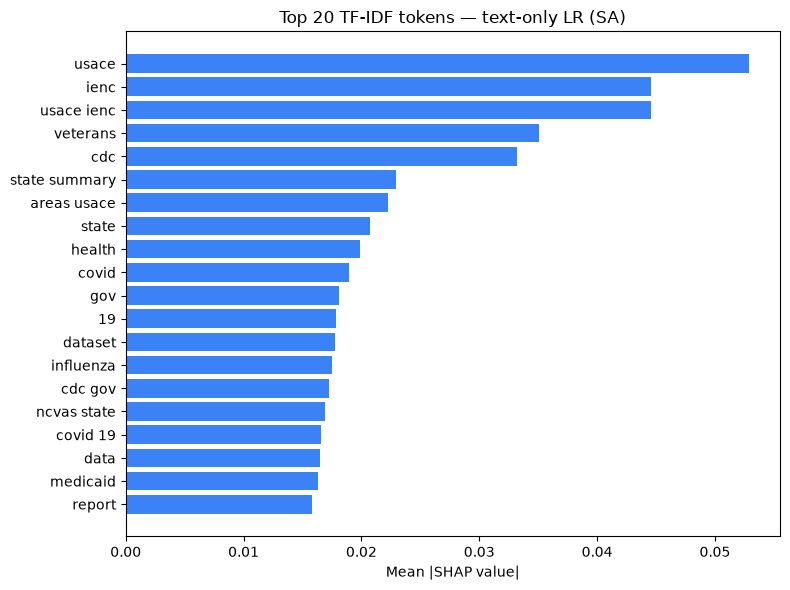

In [44]:
sv_to_o = sv_orig['Text only']
fn_to_o = fn_orig['Text only']
mean_to_o = np.abs(sv_to_o).mean(axis=0)
top_to_o = np.argsort(mean_to_o)[-TOP_K:][::-1]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([clean(fn_to_o[i]) for i in top_to_o][::-1],
        mean_to_o[top_to_o][::-1], color='#3B82F6')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title(f'Top {TOP_K} TF-IDF tokens — text-only LR (SA)')
plt.tight_layout(); plt.show()

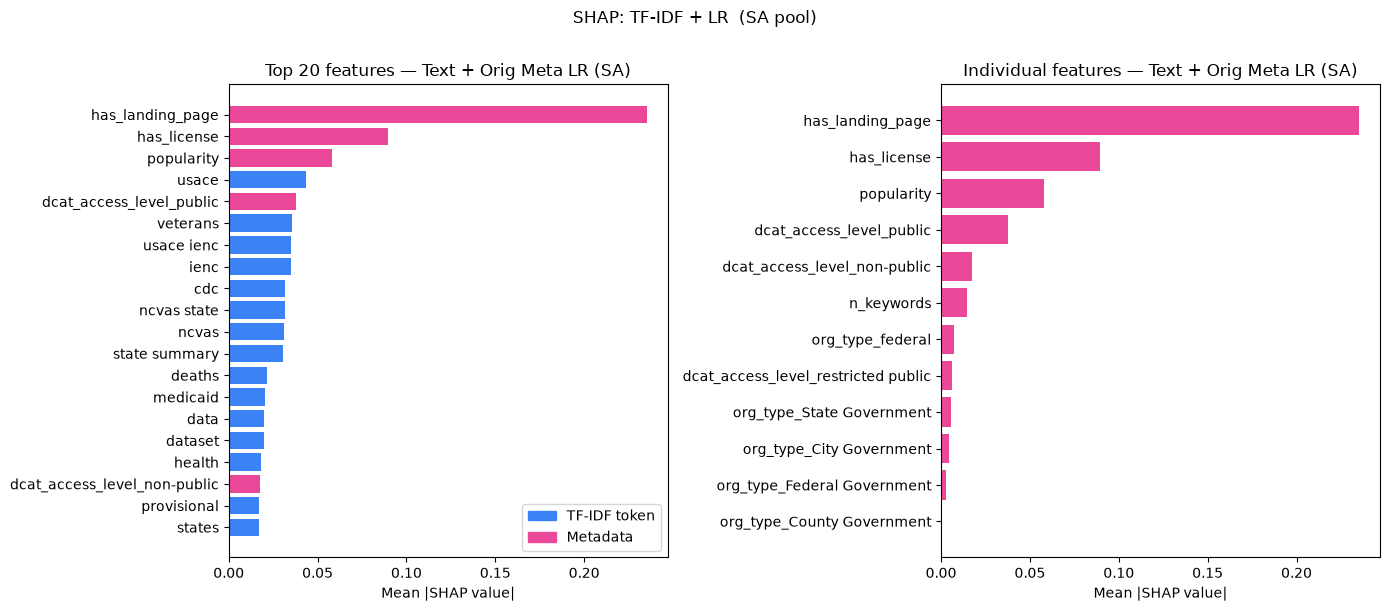

In [48]:
sv_tm_o = sv_orig['Text + Orig Meta']
fn_tm_o = fn_orig['Text + Orig Meta']
mean_tm_o = np.abs(sv_tm_o).mean(axis=0)

is_text_o = np.array([n.startswith('tfidf__') for n in fn_tm_o])
is_meta_o = ~is_text_o

top_tm_o  = np.argsort(mean_tm_o)[-TOP_K:][::-1]
colors_o = ['#3B82F6' if is_text_o[i] else '#EC4899' for i in top_tm_o]

meta_names_o = fn_tm_o[is_meta_o]
meta_shap_o  = mean_tm_o[is_meta_o]
meta_ord_o   = np.argsort(meta_shap_o)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([clean(fn_tm_o[i]) for i in top_tm_o][::-1],
             mean_tm_o[top_tm_o][::-1], color=colors_o[::-1])
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title(f'Top {TOP_K} features — Text + Orig Meta LR (SA)')
axes[0].legend(handles=[
    mpatches.Patch(color='#3B82F6', label='TF-IDF token'),
    mpatches.Patch(color='#EC4899', label='Metadata'),
], loc='lower right')
axes[1].barh([clean(n) for n in meta_names_o[meta_ord_o]][::-1],
             meta_shap_o[meta_ord_o][::-1], color='#EC4899')
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('Individual features — Text + Orig Meta LR (SA)')
plt.suptitle('SHAP: TF-IDF + LR  (SA pool)', y=1.01)
plt.tight_layout(); plt.show()

In [47]:
text_c_o = mean_tm_o[is_text_o].sum()
meta_c_o = mean_tm_o[is_meta_o].sum()
total_o  = text_c_o + meta_c_o

print(f'tf idf + meta mean absolute attribution')
print(f"tf idf tokens: {text_c_o:.4f}  ({text_c_o/total_o*100:.1f}%)")
print(f"metadata features: {meta_c_o:.4f}  ({meta_c_o/total_o*100:.1f}%)")
print(f"metadata by feature:")
for i in meta_ord_o:
    print(f"    {clean(meta_names_o[i]):<40s}  {meta_shap_o[i]:.5f}")

tf idf + meta mean absolute attribution
tf idf tokens: 3.5154  (88.0%)
metadata features: 0.4792  (12.0%)
metadata by feature:
    has_landing_page                          0.23520
    has_license                               0.08938
    popularity                                0.05802
    dcat_access_level_public                  0.03790
    dcat_access_level_non-public              0.01753
    n_keywords                                0.01457
    org_type_federal                          0.00744
    dcat_access_level_restricted public       0.00630
    org_type_State Government                 0.00568
    org_type_City Government                  0.00432
    org_type_Federal Government               0.00274
    org_type_County Government                0.00012


#### Rmbeddings + lr

In [50]:
orig_meta_pre = ColumnTransformer([
    ('num', make_pipeline(SimpleImputer(strategy='median'), StandardScaler()), orig_num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), orig_cat_cols),
], remainder='drop')
orig_meta_pre.fit(df.iloc[trainval_idx][orig_num_cols + orig_cat_cols])
orig_meta = orig_meta_pre.transform(df[orig_num_cols + orig_cat_cols])

X_b6_orig = np.hstack([X_b4_full, orig_meta]).astype(np.float32)

In [ ]:
lr_emb_orig = LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced')
lr_emb_orig.fit(X_b6_orig[trainval_idx], y_full[trainval_idx])

expl_emb_orig = shap.LinearExplainer(lr_emb_orig, bg_orig(X_b6_orig[trainval_idx]), max_samples=300)
sv_emb_orig   = expl_emb_orig.shap_values(X_b6_orig[test_idx])

n_emb_o = X_b4_full.shape[1]
is_emb_o  = np.array([True] * n_emb_o + [False] * orig_meta.shape[1])
is_meta_b6_o = ~is_emb_o
mean_emb_o = np.abs(sv_emb_orig).mean(axis=0)

emb_c_o = mean_emb_o[is_emb_o].sum()
meta_c_b6_o = mean_emb_o[is_meta_b6_o].sum()
total_b6_o = emb_c_o + meta_c_b6_o

meta_names_emb_o = np.array([clean(n) for n in orig_meta_pre.get_feature_names_out()])
meta_shap_emb_o  = mean_emb_o[is_meta_b6_o]
meta_ord_emb_o   = np.argsort(meta_shap_emb_o)[::-1]

print(f'embeddings + meta mean absolute shap attribution')
print(f"embeddings ({n_emb_o} dims): {emb_c_o:.4f}  ({emb_c_o/total_b6_o*100:.1f}%)")
print(f"metadata features {meta_c_b6_o:.4f}  ({meta_c_b6_o/total_b6_o*100:.1f}%)")
print(f"\n  Individual metadata features:")
for n, v in zip(meta_names_emb_o[meta_ord_emb_o], meta_shap_emb_o[meta_ord_emb_o]):
    print(f"    {n:<40s}  {v:.5f}")

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


embeddings + meta mean absolute shap attribution
embeddings (1536 dims): 8.3827  (94.6%)
metadata features 0.4802  (5.4%)

  Individual metadata features:
    has_landing_page                          0.28779
    popularity                                0.07171
    dcat_access_level_public                  0.04891
    dcat_access_level_non-public              0.02574
    n_keywords                                0.02087
    has_license                               0.01162
    dcat_access_level_restricted public       0.00697
    org_type_City Government                  0.00382
    org_type_Federal Government               0.00094
    org_type_federal                          0.00091
    org_type_County Government                0.00065
    org_type_State Government                 0.00030


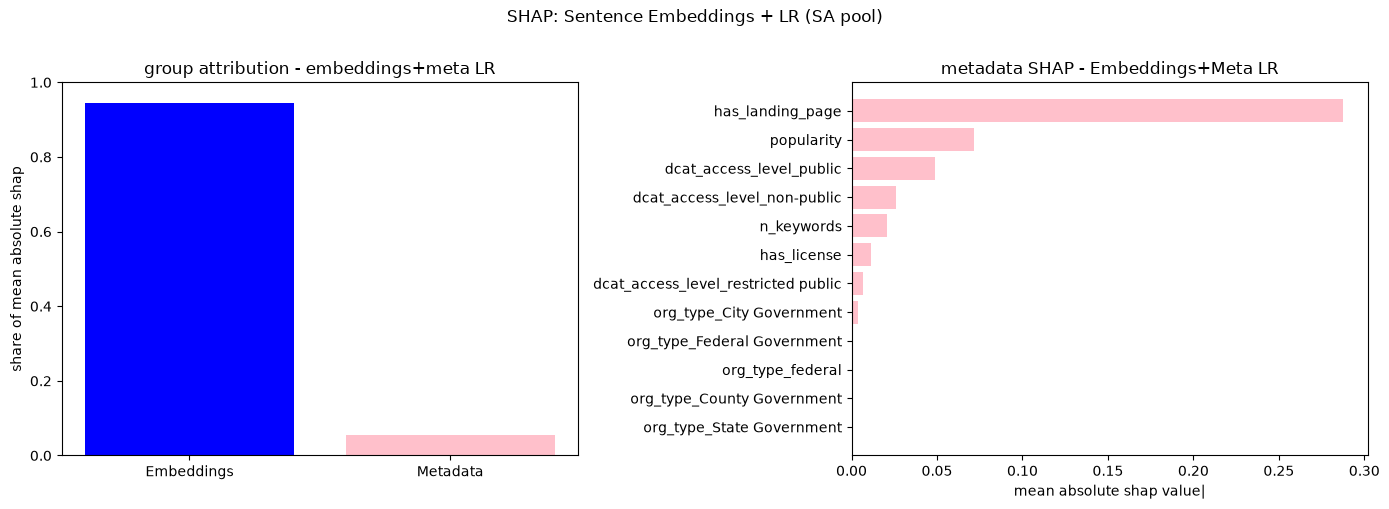

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(['Embeddings', 'Metadata'],
            [emb_c_o / total_b6_o, meta_c_b6_o / total_b6_o],
            color=['blue', 'pink'])
axes[0].set_ylabel('share of mean absolute shap')
axes[0].set_title('group attribution - embeddings+meta LR')
axes[0].set_ylim(0, 1)

axes[1].barh(meta_names_emb_o[meta_ord_emb_o][::-1],
             meta_shap_emb_o[meta_ord_emb_o][::-1], color='pink')
axes[1].set_xlabel('mean absolute shap value|')
axes[1].set_title('metadata SHAP - Embeddings+Meta LR')
plt.suptitle('SHAP: Sentence Embeddings + LR (SA pool)', y=1.01)
plt.tight_layout(); plt.show()

more shap

In [61]:
RNG_MO = RNG_ORIG 

In [60]:
def _bg_mo(X, n=300):
    idx = RNG_MO.choice(X.shape[0], min(n, X.shape[0]), replace=False)
    return X[idx]


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


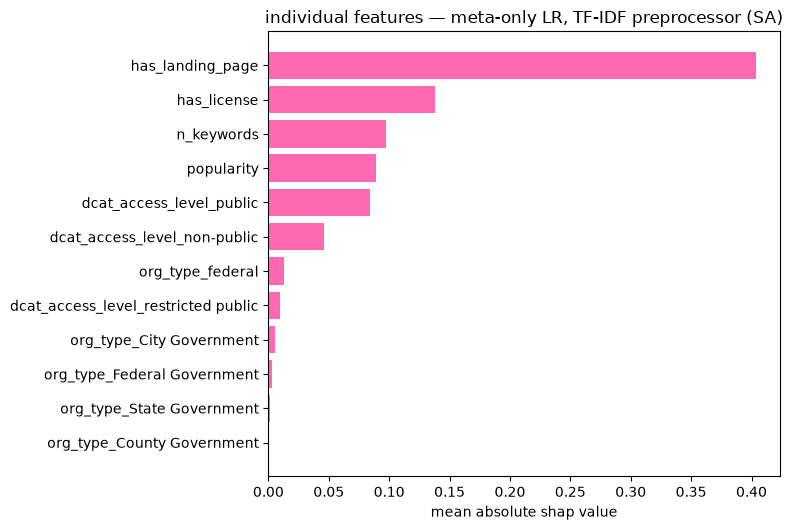

In [63]:
pipe_mo = make_ablation_pipeline(orig_num_cols, orig_cat_cols, include_text=False)
pipe_mo.fit(df[['all_text'] + orig_num_cols + orig_cat_cols].iloc[trainval_idx],
            y_full[trainval_idx])

pre_mo = pipe_mo.named_steps['pre']
lr_mo = pipe_mo.named_steps['lr']
X_tr_mo = pre_mo.transform(df[['all_text'] + orig_num_cols + orig_cat_cols].iloc[trainval_idx])
X_te_mo = pre_mo.transform(df[['all_text'] + orig_num_cols + orig_cat_cols].iloc[test_idx])

fn_mo = np.array(pre_mo.get_feature_names_out())
expl_mo = shap.LinearExplainer(lr_mo, _bg_mo(X_tr_mo), max_samples=300)
sv_mo = expl_mo.shap_values(X_te_mo)

mean_mo     = np.abs(sv_mo).mean(axis=0)
meta_ord_mo = np.argsort(mean_mo)[::-1]

fig, ax = plt.subplots(figsize=(8, max(4, len(fn_mo) * 0.45)))
ax.barh([clean(fn_mo[i]) for i in meta_ord_mo][::-1],
        mean_mo[meta_ord_mo][::-1], color='hotpink')
ax.set_xlabel('mean absolute shap value')
ax.set_title('individual features — meta-only LR, TF-IDF preprocessor (SA)')
plt.tight_layout(); plt.show()

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


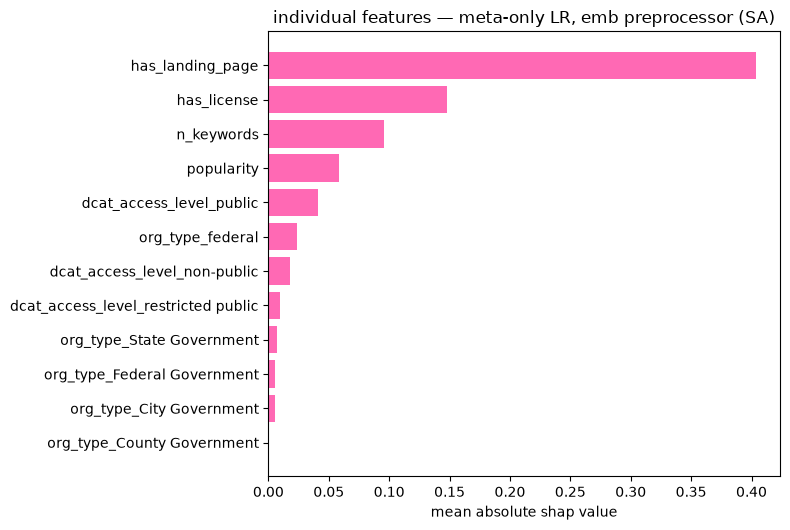

In [66]:
lr_mo_emb = LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced')
lr_mo_emb.fit(orig_meta[trainval_idx], y_full[trainval_idx])

expl_mo_emb = shap.LinearExplainer(lr_mo_emb, _bg_mo(orig_meta[trainval_idx]), max_samples=300)
sv_mo_emb = expl_mo_emb.shap_values(orig_meta[test_idx])

meta_fn_emb = np.array([clean(n) for n in orig_meta_pre.get_feature_names_out()])
mean_mo_emb = np.abs(sv_mo_emb).mean(axis=0)
meta_ord_mo_emb = np.argsort(mean_mo_emb)[::-1]

fig, ax = plt.subplots(figsize=(8, max(4, len(meta_fn_emb) * 0.45)))
ax.barh(meta_fn_emb[meta_ord_mo_emb][::-1],
        mean_mo_emb[meta_ord_mo_emb][::-1], color='hotpink')
ax.set_xlabel('mean absolute shap value')
ax.set_title('individual features — meta-only LR, emb preprocessor (SA)')
plt.tight_layout(); plt.show()

In [69]:
print("Meta only (emb preprocessor) — individual feature attribution (SA pool)")
for n, v in zip(meta_fn_emb[meta_ord_mo_emb], mean_mo_emb[meta_ord_mo_emb]):
    print(f"  {n:<40s}  {v:.5f}")


Meta only (emb preprocessor) — individual feature attribution (SA pool)
  has_landing_page                          0.40342
  has_license                               0.14819
  n_keywords                                0.09552
  popularity                                0.05855
  dcat_access_level_public                  0.04143
  org_type_federal                          0.02349
  dcat_access_level_non-public              0.01825
  dcat_access_level_restricted public       0.00986
  org_type_State Government                 0.00684
  org_type_Federal Government               0.00566
  org_type_City Government                  0.00513
  org_type_County Government                0.00010


#### IN SEABORN

In [79]:
sns.set_theme(style='whitegrid', font_scale=1.5)

In [80]:
GROUP_COLS = [
    ('Flagged risk terms', flagged_cols),
    ('Text properties', text_prop_cols),
    ('Engagement',  engagement_cols),
    ('Completeness', completeness_cols),
    ('Org type', org_cat_cols),
    ('Access level', access_cat_cols),
]

GROUP_ORDER = [
    'Text', 'Flagged risk terms', 'Text properties',
    'Engagement', 'Completeness', 'Org type', 'Access level',
]
GROUP_COLORS = {
    'Text':               'steelblue',
    'Flagged risk terms': 'firebrick',
    'Text properties':    'mediumpurple',
    'Engagement':         'cornflowerblue',
    'Completeness':       'darkslateblue',
    'Org type':           'deeppink',
    'Access level':       'hotpink',
}

In [81]:
def assign_group(feat_name):
    if feat_name.startswith('tfidf__'):
        return 'Text'
    bare = feat_name.split('__', 1)[-1] if '__' in feat_name else feat_name
    for group, cols in GROUP_COLS:
        for col in cols:
            if bare == col or bare.startswith(col + '_'):
                return group
    return 'Other'

In [82]:
X_shap = df[input_cols]

pipes = {
    'Text only':   make_ablation_pipeline([], [], include_text=True),
    'Text + Meta': make_ablation_pipeline(all_meta_num, all_meta_cat, include_text=True),
}

shap_sv, shap_fn = {}, {}

for cond, pipe in pipes.items():
    pipe.fit(X_shap.iloc[trainval_idx], y_full[trainval_idx])
    pre = pipe.named_steps['pre']
    lr  = pipe.named_steps['lr']

    X_tr = pre.transform(X_shap.iloc[trainval_idx])
    X_te = pre.transform(X_shap.iloc[test_idx])

    feat_names = np.array(pre.get_feature_names_out())  # tfidf__word, num__col, cat__col_val

    explainer = shap.LinearExplainer(lr, bg_orig(X_tr))
    shap_sv[cond] = explainer.shap_values(X_te) # (n_test, n_features)
    shap_fn[cond] = feat_names
    print(f'{cond:<14} - {feat_names.shape[0]:,} features')

Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


Text only      - 10,000 features


Background dataset has 300 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=300 when initializing the masker.


Text + Meta    - 10,023 features


In [83]:
sv = shap_sv['Text + Meta']
fn = shap_fn['Text + Meta']
mean_sv = np.abs(sv).mean(axis=0)

totals = {}
for feat, val in zip(fn, mean_sv):
    g = assign_group(feat)
    totals[g] = totals.get(g, 0.0) + val
total_tm = sum(totals.values())
pct_tm = {g: v / total_tm * 100 for g, v in totals.items()}

In [84]:
sv = sv_emb_orig
mean_sv = np.abs(sv).mean(axis=0)
meta_fn = orig_meta_pre.get_feature_names_out()

totals = {'Text': mean_sv[:n_emb_o].sum()}
for feat, val in zip(meta_fn, mean_sv[n_emb_o:]):
    g = assign_group(feat)
    totals[g] = totals.get(g, 0.0) + val
total_emb = sum(totals.values())
pct_b6 = {g: v / total_emb * 100 for g, v in totals.items()}

In [85]:
rows = []
for g in GROUP_ORDER:
    if g in pct_tm:
        rows.append({'Group': g, 'Model': 'TF-IDF + LR',     'pct': pct_tm[g]})
    if g in pct_b6:
        rows.append({'Group': g, 'Model': 'Embeddings + LR', 'pct': pct_b6[g]})
df_groups = pd.DataFrame(rows)

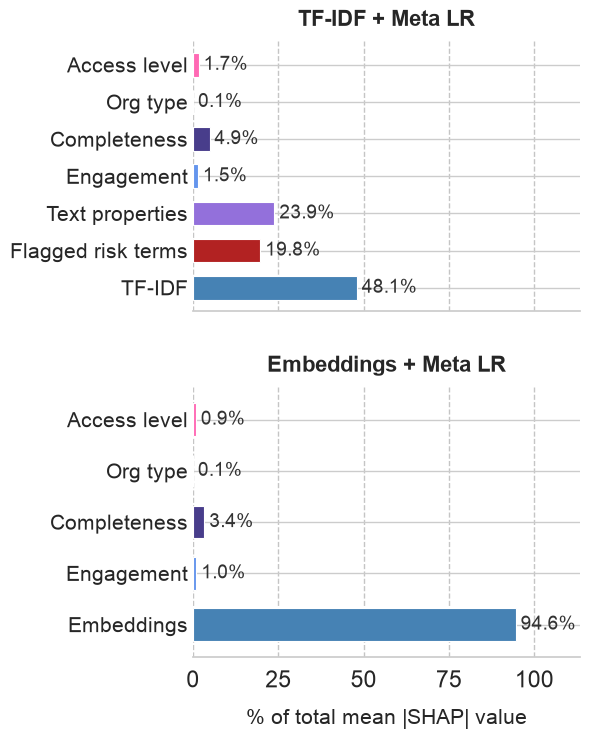

In [89]:
TEXT_LABELS = {'TF-IDF + LR': 'TF-IDF', 'Embeddings + LR': 'Embeddings'}
MODEL_TITLES = {'TF-IDF + LR': 'TF-IDF + Meta LR', 'Embeddings + LR': 'Embeddings + Meta LR'}
global_max = df_groups['pct'].max()

fig, axes = plt.subplots(2, 1, figsize=(5, 8), sharex=True)
plt.subplots_adjust(hspace=0.28)

for ax, model in zip(axes, ['TF-IDF + LR', 'Embeddings + LR']):
    sub = df_groups[df_groups['Model'] == model].copy()
    sub = sub.set_index('Group').reindex(GROUP_ORDER).dropna().reset_index()

    display_labels = [TEXT_LABELS[model] if g == 'Text' else g for g in sub['Group']]
    colors = [GROUP_COLORS[g] for g in sub['Group']]
    vals = sub['pct'].values
    y_pos = np.arange(len(vals)) * 0.55

    bars = ax.barh(y_pos, vals, color=colors, height=0.35, edgecolor='white', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(display_labels, fontsize=15)
    ax.set_title(MODEL_TITLES[model], fontsize=16, fontweight='bold', pad=11)
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, linestyle='--', alpha=0.45, color='grey')
    ax.set_axisbelow(True)
    ax.set_xlim(0, global_max * 1.2)
    ax.set_ylim(-0.35, (len(vals) - 1) * 0.55 + 0.35)

    for bar, val in zip(bars, vals):
        ax.text(bar.get_width() + global_max * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', ha='left',
                fontsize=14, color='#333333', fontweight='medium')

    sns.despine(ax=ax, left=True, bottom=False)

axes[1].set_xlabel('% of total mean |SHAP| value', labelpad=12, fontsize=15)
plt.show()